# Team Allocation Simulator - SC1003 Mini Project (FECD1 Group 2)

## Contributors:

1. Chua **Yee Han** (CHUA1142@e.ntu.edu.sg)
2. Ho Jun De **Dillon** Trevor (HOJU0016@e.ntu.edu.sg)
3. Hoo **Jia Mei** (JHOO004@e.ntu.edu.sg)
4. I Putu **Dickson** Partha Hartopo (DICKSON002@e.ntu.edu.sg)
---

## Project Overview

This notebook implements a team formation system that creates balanced, diverse, and fair student teams for 120 tutorial groups consisting of 50 students each. The system optimizes for three key factor:

- Gender Diversity (40% weight)
- School Diversity (30% weight)
- CGPA Fairness (30% weight)

---

## Executive Summary

### Problem Statement

Create fair and diverse teams across 120 student tutorial group where:
-  Teams are to be formed
only using members from the same tutorial group
- Teams include students from different schools to ensure a mix of knowledge and skills
- Teams have balanced gender representation to promote gender diversity
- Teams have fair CGPA distribution to ensure academic fairness

However, some **tolerance** is acceptable, if it happens
that a tutorial group is dominated by students from the same background or profile

---

### Key Metric Used

We realize that **diversity** and **fairness** are too vague. Thus, we need to find a metric to measure each team quality based on how diverse their gender and school distribution and how fair are the teams' CGPA relative to their tutorial groups. We also normalize the evaluation so that each metric will give score from 0 (worst quality) to 1 (best quality)

#### 1. Diversity Measure: Simpson Index

The Simpson diversity index is a quantitative measure of diversity that considers both the number of categories (richness) and their relative abundance (evenness). For this project, we use a modified version (i.e. N(N-1) version instead of N^2). We use the modified version due to the size of our teams being relatively small. We also normalize the score so that the maximum diversity possible always get score 1.0

**Why We Use Simpson Index**

1. **Intuitive Interpretation**: The version of Simpson Index that we use measure the probability that two randomly picked objects from a category sequence belong to a **different** category. A score of 0.6 means that there is 60% chance of diversity when we pick two random samples.
2. **Favor Smooth Distribution**: Simpson Index penalizes extreme imbalance and rewards even distribution. For example, if we have to separate 8 females and 2 males, Simpson Index will give two teams with 4 females and 1 male each a higher score compared to a distribution with 5 females, 0 males and 3 females, 2 males.
3. **Applicable to Multiple Categories**: Simpson Index can be applied to evaluate both gender and school diversity. It can also be averaged or weighted across these categories.

#### 2. Fairness Measure: Mean and Std Evaluation
In order to form a balanced team, the members should not be dominated by students with either very high or very low CGPAs. Moreover, it would be unfair if a team consists of students with very similar CGPAs (low standard deviation) while other teams have more diverse CGPA distributions.
Since teams can only be formed within the same tutorial group, each team’s mean and standard deviation of CGPA should be similar to those of the tutorial group.

**Calculation Detail**
- We use normalized gaussian similarity score (the y-coordinate of bell curve) to calculate how much team CGPA and tutorial group CGPA deviates
- We calculate the deviation of the mean and standard deviation of team and compared it with tutorial group statistic
- We give 70% weightage to mean and 30% weightage to standard deviation
- The metric will give 1.0 score if team mean and standard deviation exactly match their tutorial group

---
### Constraint Enforcement

Based on the problem statement we need to ensure that the teams formed has no gender majority or school majority. The school majority constraint is easily enforced since there is no tutorial group that is dominated by certain school. However, some tutorial groups may have unbalanced gender proportions (e.g. 35 females and 15 males) which forces us to accept teams where females dominate (e.g. 4 females and 1 male). Thus, we make two rejection functions as follows:

#### 1. **Gender Rejection**
- 20% Tolerance: Only accept teams if female proportion of the team differs by less than 20% compared to the female proportion of tutorial group
- For example, if tutorial group consists of 35 females (70% of the class), we only accept teams with 50% to 90% females (e.g. 3 females 2 males or 4 females 1 male)
- This ensures gender balance while giving tolerance to tutorial groups with difficult demographics

#### 2. **School Rejection**
- 50% Rule: Only accept teams where no school contributes to more than 50% of the team members' schools
- For example, if the `team_size` is 5, any teams with 3 or more members from the same school will be rejected

This team rejection function ensures that no teams formed will violate any majority constraint

---
### Implementation (Two Phase Solution)

#### Phase 1: Initial Team Formation using CGPA Clustering

- Sort student based on CGPA and cluster students by CGPA into 5 groups (High, Medium-High, Medium, Medium-Low, Low). The number of clusters is based on the `team_size`

- Assign one student from each cluster to each team to ensure every team has mixed academic abilities

- Result: Teams with balanced CGPA, but might lack gender/school diversity



#### Phase 2: Improving Team Formation through Swapping Optimization.
 After creating balanced and fair teams, we need to improve the school and gender diversity of teams formed by using a swapping algorithm:


- First, select two random teams accross the tutorial group and randomly select one member from each team. Try to swap those two members
- If the formation after the swap violates either school or gender diversity constraints, the swap will not be executed
- Calculate combined quality score before and after swaps
- Keep the teams formed only if the total score of both teams improve
- Repeat 400 times accross 120 tutorial groups

---

## Main Flowchart

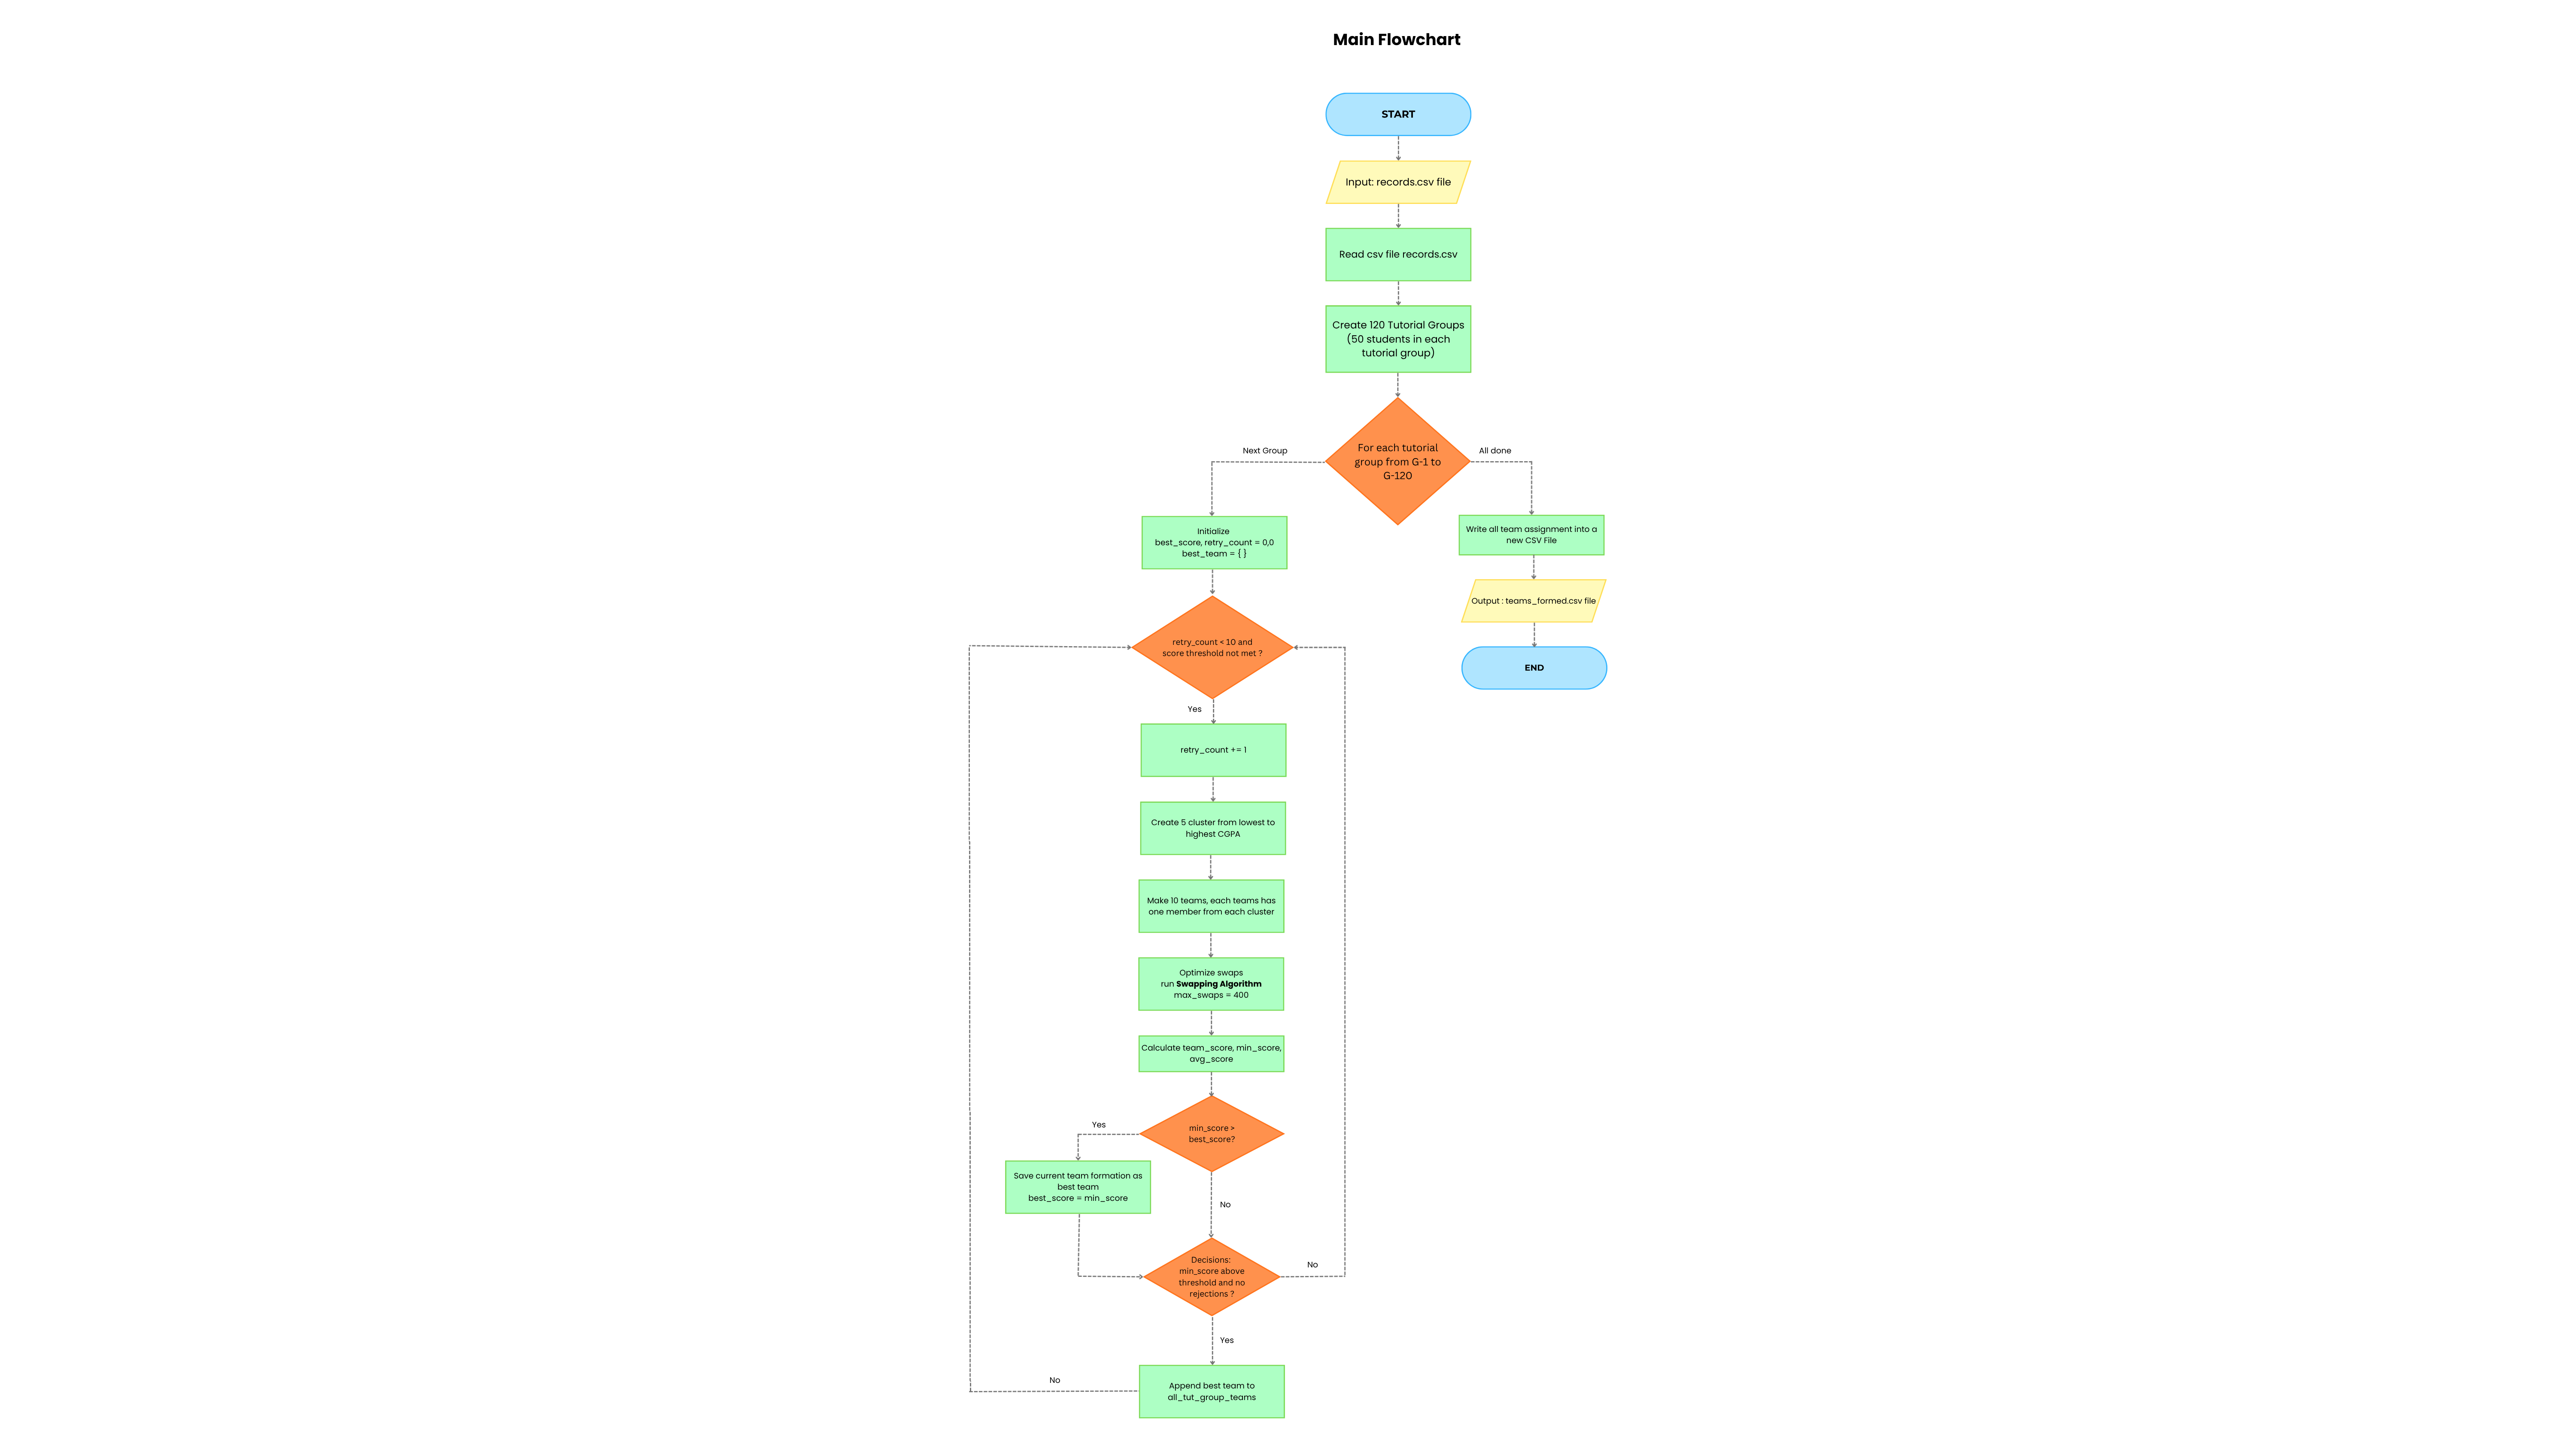

In [ ]:
from IPython.display import Image, display

display(Image(filename='assets/Main Flowchart.png'))

# Implementation Details

---
## Tables of Contents:

1. Global Parameters
2. Read CSV File
3. Formation of Tutorial Groups
4. Diversity and Fairness Metrics
5. Phase 1: CGPA Clustering
6. Constraint Enforcement
7. Phase 2: Swap Optimization
8. Multi-Attempt Team Formation Strategy
9. CSV Export

---

## 1. Global Paramaters


In [ ]:
import math, random
import matplotlib.pyplot as plt

team_size = 5 #people per team
weight = { 'School': 0.3, 'Gender': 0.4, 'CGPA':0.3 }

**Purpose**: Initialize the core parameters for team formation

**Parameters Explained**:
- `team_size = 5`: Each team will contain exactly 5 students
- `weight` dictionary: Defines how much each factor contributes to the overall team score
  - `School: 0.3` (30%): Emphasizes school diversity to bring different perspectives
  - `Gender: 0.4` (40%): Ensures gender balance for inclusive collaboration
  - `CGPA: 0.3` (30%): Guarantees fair academic performance distribution

**Why these weights?**
- School and CGPA are weighted equally because:
  - School diversity ensures varied academic backgrounds and approaches
  - CGPA fairness prevents "superteams" or "weak teams"
- Gender is slightly higher as gender imbalance is more obvious than school or CGPA imbalance

---

## 2. Read CSV file

In [ ]:
def read_csv(file_name):
    with open(file_name, "r") as file:
        lines = file.readlines()

    rows = [] #list to store csv row
    for line_str in lines:
        rows.append(line_str.strip().split(','))
    category = rows[0]

    student_dict_list = []#list to store student dict
    for row in rows[1:]: #skip first row
        if len(row) != len(category):
            return 'error'
        student_dict = {}
        for i in range(len(category)):
            student_dict[category[i]] = row[i]
        student_dict_list.append(student_dict)
    return student_dict_list

### Function: `read_csv(file_name)`

**Purpose**: Reads a CSV file containing student records and converts it into a structured list of dictionaries

**Input**:
- `file_name` (string): Path to the CSV file (e.g., "records.csv")

**Output**:
- List of dictionaries where each dictionary represents one student
- Returns `'error'` if data is malformed

**Process Breakdown**:

#### Step 1: Read and Parse CSV Lines
```python
  rows = []
    for line_str in lines:
        rows.append(line_str.strip().split(','))
```
- Reads each line from the file
- `strip()`: Removes leading/trailing whitespace and newline characters
- `split(',')`: Separates each line into a list using comma as delimiter
- Result: `rows` is a 2D list (list of lists)

#### Step 2: Extract Column Headers
`category = rows[0]`

- First row contains column headers (Tutorial Group, Student ID, School, Name, Gender, CGPA)

#### Step 3: Convert Rows to Dictionaries
```python
student_dict_list = []
for row in rows[1:]:  
    if len(row) != len(category):
        return 'error'
    
    student_dict = {}
    for i in range(len(category)):
        student_dict[category[i]] = row[i]
    student_dict_list.append(student_dict)
```

**What's happening here?**
- `rows[1:]`: Skips the first row (headers) and processes data rows
- **Error checking**: Ensures each row has the same number of columns as headers
  - If mismatch detected → returns `'error'`
  - Prevents corrupt data from breaking the system
- Creates a dictionary for each student mapping column names to values

**Example transformation**:
``` python
CSV Row: ['G-109', '1960', 'SPMS', 'Ajay Reddy', 'Male', '4.17']
Dictionary: {
    'Tutorial Group': 'G-109',
    'Student ID': '1960',
    'School': 'SPMS',
    'Name': 'Ajay Reddy',
    'Gender': 'Male',
    'CGPA': '4.17'
}
```

**Final Output**: List of 6000 student dictionaries ready for processing

---

## 3. Formation of tutorial groups

In [ ]:
def create_tutorial_groups(student_list):
    groups = {} #dict to store tut group

    for student in student_list:
        group_name = student['Tutorial Group']
        if group_name not in groups:
            groups[group_name] = [] #create new list for each tut group
        groups[group_name].append(student)
    return groups

### Function: `create_tutorial_groups(student_list)`

**Purpose**: create the function that will take the list of students and group them by tutorial groups.

**Input**: `student_list` which will list all 6000 student dictionaries.

**Output**: Dictionaries with tutorial group name as keys and list consisting of student dictionaries as value.

**Process Breakdown**

#### Step 1: Initialize Dictionary

``` python
groups = {}
```

 - Initialise the dictionary which will contain all the students in same tutorial group.

#### Step 2: Iterate through Student List
``` python
for student in student_list:
        group_name = student['Tutorial Group']
```

- For loop that goes through each and every student in the cohort
- Retrieves the tutorial group name that the student belongs to using the `Tutorial Group` key.

#### Step 3: Appending Individual Student Dictionary

``` python
if group_name not in groups:
            groups[group_name] = []
groups[group_name].append(student)
            return groups
```


-  Check if the `group_name` is inside `groups` dictionary
-  Check if the group has been formed
-  If not, new list is created for the tutorial group.
-  Add students with the same group name in the same tutorial group
-  After going through all 6000 students and adding them into their respective tutorial groups such as G-1, G-2, the group dictionary will contain the students in each tutorial group.


**Grouping Example**

``` python
groups = {
    'G-1': [
        {'Tutorial Group': 'G-1',
        'Student ID': '5002',
        'School': 'CCDS',
        'Name': 'Aarav Singh',
        'Gender': 'Male',
        'CGPA': '4.02'},
        {'Tutorial Group': 'G-1',
        'Student ID': '3838',
        'School': 'EEE',
        'Name': 'Aarti Nair',
        'Gender': 'Female',
        'CGPA': '4.05'} ...
    ]
    'G-2': [
        { ... },
        { ... },
        ...
        { ... }
    ]
    ...
    'G-120': [
        { ... },
        { ... },
        ...
        { ... }
    ]
}

```


In [ ]:
student_list_all = read_csv("records.csv")
dict_list_records = create_tutorial_groups(student_list_all)
dict_list_tutorial1 = dict_list_records['G-1']

for i in dict_list_tutorial1[0:5]:
    print(i)

{'Tutorial Group': 'G-1', 'Student ID': '5002', 'School': 'CCDS', 'Name': 'Aarav Singh', 'Gender': 'Male', 'CGPA': '4.02'}
{'Tutorial Group': 'G-1', 'Student ID': '3838', 'School': 'EEE', 'Name': 'Aarti Nair', 'Gender': 'Female', 'CGPA': '4.05'}
{'Tutorial Group': 'G-1', 'Student ID': '2091', 'School': 'EEE', 'Name': 'Adlan Bin Rahman', 'Gender': 'Male', 'CGPA': '4.2'}
{'Tutorial Group': 'G-1', 'Student ID': '288', 'School': 'CoB (NBS)', 'Name': 'Ajay Verma', 'Gender': 'Male', 'CGPA': '4.01'}
{'Tutorial Group': 'G-1', 'Student ID': '4479', 'School': 'CCDS', 'Name': 'Amelia Kim', 'Gender': 'Female', 'CGPA': '4.11'}


**Usage Example**

---

## 4. Diversity and Fairness Metrics


In [ ]:
def simpson_raw_score(category_seq):
    N = len(category_seq)

    if N <= 1:
        return 0 #edge cases

    counts = {} #dict to store occurence
    for c in category_seq:
        counts[c] = counts.get(c, 0) + 1
    total_pair = (N) * (N - 1)
    category_pair = sum(n * (n - 1) for n in counts.values())

    score = 1 - category_pair / total_pair

    return score


### 4.1 Simpson Raw Score

### Function: `simpson_raw_score(category_seq)`

**The idea**: "If I randomly select 2 indivduals from this team, what is the probability they belong to different categories?"

The higher the score, the more diverse the team is

**Purpose**: Calculates the Simpson Diversity Index to measure how well-distributed different categories are within a team

**Input**:
- `category_seq`: List of category values (e.g., ['Male', 'Female', 'Male', 'Female', 'Male'])

**Output**:
- Float between 0 and 1
- 0 = no diversity (all same category)
- 1 = maximum diversity (all different categories)

**Formula**: $$D = 1 - \dfrac{\sum(n_{i}(n{i}-1))}{(N(N-1))}$$

Where:
- N = total number of individuals
- $n_{i}$ = count of individuals in category i
- $\sum$ = sum across all categories

**Step-by-Step Calculation**:

#### Step 1: Count Each Category
```python
counts = {}
for c in category_seq:
    counts[c] = counts.get(c, 0) + 1
```

**Explanation**:
- Creates a dictionary counting occurrences of each category
- `counts.get(c, 0)`: Returns current count for category `c`, or 0 if not found
- Increments count by 1

**Example**:
```python
category_seq = ['Male', 'Male', 'Female', 'Female', 'Male']
# counts = {'Male': 3, 'Female': 2}
```

#### Step 2: Calculate Total Pairs
```python
total_pair = (N) * (N - 1)
```

**Reason for (N × (N-1))?**
- This counts the ordered pairs
- Firstly, pick any of 5 students
- Secondly, pick any of remaining 4 students
- (N-1) because a student cannot be paired with their own self
- The order does not matter (i.e. picking A then B is the same as picking B then A)

Visualisation for 5 students A, B, C, D, E:
- A can pair with B, C, D, E (4 pairs)
- B can pair with A, C, D, E (4 pairs)
- C can pair with A, B, D, E (4 pairs)
- D can pair with A, B, C, E (4 pairs)
- E can pair with A, B, C, D (4 pairs)
Thus, for 5 individuals, there is a total of 5 x 4 = 20 ordered pairs

#### Step 3: Calculate Category Pairs
```python
category_pair = sum(n * (n - 1) for n in counts.values())
```

**Explanation**:
- For each category, count the number of ordered pairs that can be formed within that categories
- Sums across all categories

**Example**:
- Males: 3 students → 3 × (3-1) = 3 x 2 = 6 male-male pairs
- Females: 2 students → 2 × (2-1) = 2 x 1 = 2 female-female pairs
- Total same_category_pairs: 6 + 2 = 8

#### Step 4: Calculate Final Diversity Score
```python
score = 1 - (category_pair / total_pair)
return score
```

**The Final Calculation**:
- Probability of picking same category = 8/20 = 0.4
- Probability of picking different category = 1 - 0.4 = 0.6
- **Diversity score = 0.6** (60% diverse)

**Interpretation**:
- A diversity score of 0.6 means that if you randomly pick 2 students from this team, there is a 60% chance that they are different genders
- The higher the score, the more diverse the teams are
- A team with 3 Males and 2 Females has good diversity

In [ ]:
gender_list = ['m', 'm', 'f', 'f', 'm']
school_list = ['SSS', 'CCDS', 'CCEB', 'MAE', 'SPMS']
print(simpson_raw_score(gender_list))
print(simpson_raw_score(school_list))

0.6
1.0


**Usage Example**

In [ ]:
def simpson_diversity_count(category_seq, category_num):

    N = len(category_seq)
    total_pairs = N * (N - 1)

    if category_num >= N:
        norm = 1 #no need for normalization

    else:
        base = N // category_num #spread student as evenly as possible
        remainder = N % category_num
        num_base = category_num - remainder
        num_extra = remainder

        best_pair = (
            num_base * base * (base - 1) +
            num_extra * (base + 1) * base
        )
        norm = 1 - best_pair / total_pairs  #maximum simpson score

    raw_score = simpson_raw_score(category_seq)
    score = raw_score / norm

    return score

### 4.2 Normalized Simpson Diversity

### Function: `simpson_diversity_count(category_seq, category_num)`

**Purpose**: Normalizes the Simpson score to account for limited available categories

**Why Normalization is Needed?**

Consider these scenarios:
- **Scenario A**: 5 students from 2 genders → Raw score might be 0.6
- **Scenario B**: 5 students from 10 schools → Raw score might be 1.0

Without normalization, school diversity appears "better" simply because there are more schools available. Normalization makes scores comparable across different category types.

**Input**:
- `category_seq`: List of category values for the team
- `category_num`: Total distinct categories available in the tutorial class

**Output**: Normalized diversity score (0 to 1)

**The Normalization Process**:

#### Case 1: More Categories Than Team Size
```python
if category_num >= seq_length:
    norm = 1
```

**When this happens**:
- Team size: 5 students
- Available schools: 10 different schools
- It's theoretically possible for all 5 students to be from different schools
- Maximum achievable diversity = 1.0
- No normalization needed → factor = 1

#### Case 2: Fewer Categories Than Team Size
```python
else:
    base = N // category_num #spread student as evenly as possible
    remainder = N % category_num
    num_base = category_num - remainder
    num_extra = remainder
```

**When this happens**:
- Team size: 5 students
- Available genders: 2 (Male, Female)
- Impossible to have all different genders
- Maximum achievable diversity < 1.0
- Must normalize to make fair comparison

**Mathematical Explanation**:

When distributing N students across C categories as evenly as possible:
- Some categories get ⌈N/C⌉ students (num_base)
- Other categories get ⌊N/C⌋ students (num_extra)

**Example**: 5 students, 2 genders
- Optimal distribution: 3 Males, 2 Females (or 2 Males, 3 Females)
- `base = 5 // 2 = 2` (floor division)
- `remainder = ceil(5 / 2) = 3` (ceiling division)
- `num_base = 5 % 2 = 1` (how many categories get 3 students)
- `num_extra = 2 - 1 = 1` (how many categories get 2 students)

#### Calculate Maximum Achievable Diversity
```python
best_pair = (
            num_base * base * (base - 1) +
            num_extra * (base + 1) * base
        )
        norm = 1 - best_pair / total_pairs  
```

**What's the maximum diversity for 5 students, 2 genders?**
- 1 category with 3 students: 3 × 2 = 6 pairs
- 1 category with 2 students: 2 × 1 = 2 pairs
- Same-category pairs in optimal case: 6 + 2 = 8
- Total possible pairs: 5 × 4 = 20
- Maximum diversity = 1 - 8/20 = 0.6

**This 0.6 becomes our normalizing factor**

#### Final Normalized Score
```python
raw_score = simpson_raw_score(category_seq)
    score = raw_score / norm
    return score
```

In [ ]:
#testing normalized simpson diversity with examples from 4.1
gender_list = ['Male', 'Male', 'Female', 'Female', 'Male']
school_list = ['ADM', 'CCDS', 'EEE', 'MAE', 'SPMS']

#compare with raw scores
print("Comparison with raw scores:")
print(f"Gender raw score: {simpson_raw_score(gender_list): .1f}, Normalized: {simpson_diversity_count(gender_list, 2): .1f}")
print(f"School raw score: {simpson_raw_score(school_list): .1f}, Normalized: {simpson_diversity_count(school_list, 8): .1f}")

Comparison with raw scores:
Gender raw score:  0.6, Normalized:  1.0
School raw score:  1.0, Normalized:  1.0


**Usage Example**

In [ ]:
def gpa_fairness_count(team_cgpa, class_cgpa):

    #class stats
    class_mean = sum(class_cgpa) / len(class_cgpa)
    class_var = sum((x - class_mean) ** 2 for x in class_cgpa) / (len(class_cgpa) - 1)
    class_std = math.sqrt(class_var)

    #team stats
    team_mean = sum(team_cgpa) / len(team_cgpa)
    team_variance = sum((x - team_mean) ** 2 for x in team_cgpa) / (len(team_cgpa) - 1)
    team_std = math.sqrt(team_variance)

    #apply gaussian similarity formula
    score_mean = math.exp(-((team_mean - class_mean) ** 2) / (2 * class_std ** 2))
    score_std = math.exp(-((team_std - class_std) ** 2) / (2 * class_std ** 2))

    #final score
    return 0.7 * score_mean + 0.3 * score_std

### 4.3 CGPA Fairness Metric

### Function: `gpa_fairness_count(team_cgpa, class_cgpa)`
**The idea**: "How balanced is this team's CGPA compared to the overall tutorial class?"
- There should be no "smart teams" (concentration of all high performers)
- There should be no "weak teams" (concentration of all low performers)
- Each team should reflect the class's academic diversity
- Each team should get a balanced mix of academic abilities (based on their CGPAs)

**Purpose**: Evaluates whether a team's CGPA distribution is fair compared to the overall tutorial class

- We don't want "superteams" (all high performers)
- We don't want "weak teams" (all low performers)
- Each team should mirror the class's academic profile

**Input**:
- `team_cgpa`: List of CGPA values for team members (e.g. [4.167, 3.91, 4.01, 3.96, 3.89])
- `class_cgpa`: List of CGPA values for entire tutorial class (50 students)

**Output**:
- 1.0 = Team distribution perfectly matches the class distribution
- Anything lower = Team distribution deviates from the class distribution

**Use Two Components (Mean + Standard Deviation)?**
1. **Mean (70% weight)**:
- Ensures the team's average CGPA $\approx$ class average CGPA
- Prevents concentration of high or low performers

2. **Standard deviation (30% weight)**:
- Ensures the team's CGPA spread $\approx$ class CGPA spread
- Prevents all the team members from having similar CGPA
- Helps to promote academic diversity within the team

**Steps to calculate**:

### Step 1: Calculate Class Statistics
```python
class_mean = sum(class_cgpa) / len(class_cgpa)
class_variance = sum((x-class_mean) ** 2 for x in class_cgpa) / (len(class_cgpa) - 1)
class_std = math.sqrt(class_variance)
```

**Variance Formula**: $\sigma^{2} = \dfrac{\sum(x_{i} - \mu)²}{N-1}$
- `xᵢ`: Individual's CGPA
- `µ`: Mean CGPA
- `N-1`: Sample variance

**Example**:
- Class of 50 students
- Mean CGPA: 4.08
- Standard deviation: 0.12

#### Step 2: Calculate Team Statistics
```python
team_mean = sum(team_cgpa) / len(team_cgpa)
team_variance = sum((x - team_mean) ** 2 for x in team_cgpa) / (len(team_cgpa) - 1)
team_std = math.sqrt(team_variance)
```

**Example**:
- Team of 5 students: [4.17, 3.91, 4.01, 3.96, 3.89]
- Team mean: 3.99
- Team std: 0.11

#### Step 3: Gaussian Similarity Score

**The Gaussian (Normal Distribution) Approach**:

Uses the bell curve formula to measure how "similar" two values are:

**Formula**: $score = e^{\dfrac{-difference^{2}}{2 × \sigma^{2}}}$

**Reason for using Gaussian Approach?**
- Penalizes large deviations more heavily than small ones
- Score of 1.0 when values are identical
- Gradually decreases as difference grows
- Never goes negative

#### Mean Comparison
```python
score_mean = math.exp(-((team_mean - class_mean) ** 2) / (2 * class_std ** 2))
```

**Explanation**:
- This calculates the difference between the team mean (3.99) and class mean (4.08) = 0.09
- Squared difference: (0.09)² = 0.0081
- Normalized by class variance: 0.0081 / (2 * 0.12²) = 0.0081 / 0.0288 = 0.28
- Gaussian Score: $e^{-0.28}$ = 0.76
- This means that the team mean is 76% similar to the class mean (reasonably close)

#### Standard Deviation Comparison
```python
score_std = math.exp(-((team_std - class_std) ** 2) / (2 * class_std ** 2))
```

**Explanation**:
- This calculates the difference between the team std (0.11) and class std (0.12) = 0.01
- Squared difference: (0.01)² = 0.0001
- Normalized by class variance: 0.0001 / (2 * 0.12²) = 0.0001 / 0.0288 = 0.003
- Gaussian Score: $e^{-0.003}$ = 0.997

#### Step 4: Weighted Combination
```python
return 0.7 * score_mean + 0.3 * score_std
fairness_score = 0.7 * 0.76 + 0.3 * 0.997 = 0.532 + 0.299 = 0.831
```

**Result**:
This team achieves 83.1% fairness which is reasonably well-balanced

In [ ]:
def team_score(teams, tutorial_group):

    #get tutorial group and team cgpa
    class_cgpa = [float(d['CGPA']) for d in tutorial_group]
    team_cgpa = [float(d['CGPA']) for d in teams]

    total_school = len(set(d['School'] for d in tutorial_group))
    team_school = [d['School'] for d in teams]

    total_gender = len(set(d['Gender'] for d in tutorial_group))
    team_gender = [d['Gender'] for d in teams]

    #count each aspect score
    simp_school = simpson_diversity_count(team_school, total_school)
    simp_gender = simpson_diversity_count(team_gender, total_gender)
    cgpa_score = gpa_fairness_count(team_cgpa, class_cgpa)

    #calculate weighted score
    return weight['School'] * simp_school + weight['Gender'] * simp_gender + weight['CGPA'] * cgpa_score

### 4.4 Weighted Combination

**Function**:
team_score(team_list, tutorial_list)

**Purpose**:
Combines diversity and fairness metrics into one single comprehensive team score

**The Weighted Formula**:
```python
return (weight['School'] * school_diversity + weight['Gender'] * gender_diversity + weight['CGPA'] * cgpa_fairness)
```

**Example**:
``` python
# Component scores for a sample team
school_diversity = 0.85 # 85% of maximum school diversity
gender_diversity = 1.00 # Perfect gender diversity
cgpa_fairness = 0.83 #83% CGPA fairness

# Weighted combination
team_score = 0.30 * 0.85 + 0.40 * 1.00 + 0.30 * 0.83
team_score = 0.255 + 0.400 + 0.249 = 0.904
```


In [ ]:
for i in dict_list_records['G-30'][21:26]:
    print(i)

print(f"The team score is {team_score(dict_list_records['G-30'][21:26], dict_list_records['G-30']):.3f}")

{'Tutorial Group': 'G-30', 'Student ID': '3795', 'School': 'CCDS', 'Name': 'Jing Wei', 'Gender': 'Male', 'CGPA': '4.02'}
{'Tutorial Group': 'G-30', 'Student ID': '2942', 'School': 'MAE', 'Name': 'Kai Li', 'Gender': 'Male', 'CGPA': '4.26'}
{'Tutorial Group': 'G-30', 'Student ID': '3828', 'School': 'CCEB', 'Name': 'Kelly Lee', 'Gender': 'Female', 'CGPA': '4.15'}
{'Tutorial Group': 'G-30', 'Student ID': '3149', 'School': 'MAE', 'Name': 'Keshav Yadav', 'Gender': 'Male', 'CGPA': '4.01'}
{'Tutorial Group': 'G-30', 'Student ID': '81', 'School': 'MAE', 'Name': 'Kieran Lewis', 'Gender': 'Male', 'CGPA': '4.22'}
The team score is 0.768


**Usage Example**

---

## 5. Phase 1: CGPA Clustering


In [ ]:
def create_gpa_cluster(student_list, cluster_num = 5):
    sorted_students = sorted(student_list, key=lambda x: x['CGPA'])
    N = len(sorted_students)

    base_size = N // cluster_num #normal team size
    remainder = N % cluster_num #number of team with +1 people

    clustered_list = [] #list to store student cluster
    index = 0

    for i in range(cluster_num):
        cluster_size = base_size + (1 if i < remainder else 0)
        clustered_list.append([]) #list for each cluster
        for j in range(index, index + cluster_size):
            clustered_list[i].append(sorted_students[j])
        index += cluster_size
    return clustered_list

### 5.1 CGPA Clustering

### Function: `create_gpa_cluster(student_list, cluster_num=5)`

**Purpose** : Divides tutorial class into CGPA performance tiers to enable balanced team formation across flexible team sizes (4-10 students)

**Strategy**: Instead of randomly selecting students, we create "CGPA brackets" matching the desired team size, ensuring each team gets one member from each performance level.

**Flexibility**: Our algorithm adapts to different team sizes:
- 4-person teams → 4 CGPA clusters  
- 5-person teams → 5 CGPA clusters (current implementation)
- 10-person teams → 10 CGPA clusters


**Input**:
- `student_list`: List of 50 student dictionaries from one tutorial group
- `cluster_num`: Number of clusters (default 5, matching team size)

**Output**: List of 5 lists (clusters), each containing ~10 students

**Why This Approach?**

**Random selection without clustering might create**:

- Team A: All students with CGPA > 4.2
- Team B: All students with CGPA < 3.9
- This leads to unfair distribution

**Solution with clustering**:
- Divide students into 5 performance tiers
- Each team picks 1 from each tier
- Guarantees balanced CGPA distribution as each team has 1 student from every CGPA performance level

**Step-by-Step Process**:

#### Step 1: Sort by CGPA
```python
sorted_students = sorted(student_list, key=lambda x: x['CGPA'])
```

**Lambda function**:
- `lambda x: x['CGPA']`: Anonymous function that extracts CGPA from each student dictionary
- `sorted()` function then sorts the students based on the extracted CGPA from each student dictionary
- Sorts students from lowest to highest CGPA
- Example: [3.85, 3.89, 3.90, ..., 4.26, 4.30]

#### Step 2: Calculate Cluster Sizes
```python
base_size = N // cluster_num
remainder = N % cluster_num
```

**Calculation**:
- Tutorial group: 50 students
- Clusters: 5
- Ideal size: 50 ÷ 5 = 10 students per cluster
- `base_size = 50 // 5 = 10`
- `remainder = 50 % 5 = 0` (no remainder)

**What if there's a remainder?**
- For remainder  = r, first r groups will be allocated 1 extra student

Example: 50 students, 8 clusters
- `base_size = 50 // 8 = 6`
- `remainder = 52 % 5 = 2`
- First 2 clusters get 7 students
- Last 3 clusters get 6 students
- Total: 2 * 7 + 6 * 6 = 50 ✓

#### Step 3: Distribute Students into Clusters
```python
clustered_list = []
index = 0

for i in range(cluster_num):
    cluster_size = base_size + (1 if i < remainder else 0)
    clustered_list.append([])
    for j in range(index, index + cluster_size):
        clustered_list[i].append(sorted_students[j])  
    index += cluster_size
```

**Explanation**

1. `for i in range(cluster_num)`: Outer for loop iterates for each cluster
2. `cluster_size = base_size + (1 if i < remainder else 0)`
   - Adds 1 extra student to first `remainder` clusters
   - Example: If remainder=2, size of clusters 0 and 1 increased by 1

3. Inner loop: `for j in range(index, index + cluster_size)`
   - `clustered_list[i].append(sorted_students[j]) `: Slices the sorted student list and appends it to the clustered student list
   - `index` keeps track of the index of the next student in `sorted_students` list to be appended in the next cluster

In [ ]:
student_gpa_cluster = create_gpa_cluster(dict_list_tutorial1, team_size)
print("CGPA Clusters created:")
for i, cluster in enumerate(student_gpa_cluster):
    cgpas = [float(s['CGPA']) for s in cluster]
    print(f"Cluster {i + 1}: {len(cluster)} students, CGPA range: {min(cgpas):.2f} - {max(cgpas):.2f}")

CGPA Clusters created:
Cluster 1: 10 students, CGPA range: 3.85 - 4.02
Cluster 2: 10 students, CGPA range: 4.02 - 4.06
Cluster 3: 10 students, CGPA range: 4.06 - 4.11
Cluster 4: 10 students, CGPA range: 4.11 - 4.18
Cluster 5: 10 students, CGPA range: 4.19 - 4.52


**Usage Example**

In [ ]:
def form_teams_from_clusters(student_clusters, team_size):

    total_students = sum(len(cluster) for cluster in student_clusters)
    num_teams = total_students // team_size

    initial_formation = {f'Team {i + 1}': []  for i in range(num_teams)} #dict to store team

    for i in range(num_teams):
        for cluster in student_clusters:
            if cluster:
                random_student = random.choice(cluster) #take 1 random student from each cluster
                initial_formation[f'Team {i + 1}'].append(random_student)
                cluster.remove(random_student)

    for i in range(len(student_clusters)):
        if student_clusters[i]:
            initial_formation[f'Team {i + 1}'].append(student_clusters[i][0]) #distribute leftover
            student_clusters[i].clear()

    return initial_formation

### 5.2 Initial Team Formation

### Function: `form_teams_from_clusters(student_clusters, team_size)`

**Purpose**: Creates initial teams by selecting one member from each CGPA cluster

**The Strategy**:
- 50 students ÷ 5 per team = 10 teams
- 5 clusters with 10 students each
- Each team gets 1 student from each cluster
- Guarantees CGPA balance from the start

**Input**:
- `student_clusters`: List of 5 lists (output from `create_gpa_cluster`)
- `team_size`: Number of students per team (5)

**Output**: Dictionary with team names as keys, each containing list of 5 students

**Process**:

#### Step 1: Calculate Number of Teams
```python
total_students = sum(len(cluster) for cluster in student_clusters)
num_teams = total_students // team_size
```

- Total: 10 + 10 + 10 + 10 + 10 = 50 students
- Teams: 50 ÷ 5 = 10 teams

#### Step 2: Create Empty Team Dictionary
```python
initial_formation = {f'Team {i + 1}': []  for i in range(num_teams)}
```

**Creates**:
```python
{
    'Team 1': [],
    'Team 2': [],
    ...
    'Team 10': []
}
```

#### Step 3: Distribute Students (Round-Robin Style)
```python
for i in range(num_teams):
    for cluster in student_clusters:
        if cluster:
            random_student = random.choice(cluster)
            initial_formation[f'Team {i + 1}'].append(random_student)
            cluster.remove(random_student)
```

**What's happening in the nested loop?**

**Outer loop** (i = 0 to 9): Iterates through each team

**Inner loop**: Visits each of the 5 clusters

**For Team 1 (i=0)**:
1. Visit Cluster 0 (lowest CGPA) → Pick random student → Add to Team 1 → Remove from cluster
2. Visit Cluster 1 (low-mid CGPA) → Pick random student → Add to Team 1 → Remove from cluster
3. Visit Cluster 2 (mid CGPA) → Pick random student → Add to Team 1 → Remove from cluster
4. Visit Cluster 3 (mid-high CGPA) → Pick random student → Add to Team 1 → Remove from cluster
5. Visit Cluster 4 (highest CGPA) → Pick random student → Add to Team 1 → Remove from cluster

Result: Team 1 now has 5 students with balanced CGPA

**After all 10 teams**: Each cluster is now empty (all students distributed)

**Why `random.choice()`?**
- Within each CGPA cluster, students are academically similar
- Random selection adds diversity in other factors (gender, school)
- Prevents predictable patterns

#### Step 4: Handle Leftover Students (If Any)
```python
for i in range(len(student_clusters)):
    if student_clusters[i]:
        initial_formation[f'Team {i + 1}'].append(student_clusters[i][0])
        student_clusters[i].clear()
```

**When does this happen?**
- If student count doesn't divide evenly by team size
- Example: 50 students, 6 per team = 8 full teams + 2 leftover
- These 2 students get added to Teams 1 and 2

**In our case**: 50 students ÷ 5 = 10 exactly, so this section doesn't activate

**Final Output Structure**:
```python
{
    'Team 1': [
        {student from cluster 0},
        {student from cluster 1},
        {student from cluster 2},
        {student from cluster 3},
        {student from cluster 4}
    ],
    'Team 2': [...],
    ...
    'Team 10': [...]
}
```

In [ ]:
teams_formed = form_teams_from_clusters(student_gpa_cluster, team_size)

print("\nTeams formed:")
for team_name, members in teams_formed.items():
    cgpas = [float(s['CGPA']) for s in members]
    avg_cgpa = sum(cgpas)/len(cgpas) if cgpas else 0
    print(f"{team_name}: {len(members)} students, Average CGPA: {avg_cgpa:.2f}")



Teams formed:
Team 1: 5 students, Average CGPA: 4.07
Team 2: 5 students, Average CGPA: 4.07
Team 3: 5 students, Average CGPA: 4.08
Team 4: 5 students, Average CGPA: 4.09
Team 5: 5 students, Average CGPA: 4.10
Team 6: 5 students, Average CGPA: 4.08
Team 7: 5 students, Average CGPA: 4.10
Team 8: 5 students, Average CGPA: 4.09
Team 9: 5 students, Average CGPA: 4.14
Team 10: 5 students, Average CGPA: 4.14


**Usage Example**

## 6. Constraint Enforcement

After teams are formed, we need to check if they meet diversity requirements. Two rejection criteria act as "quality control" filters.

In [ ]:
def gender_rejection(team, tutorial_class):

    #get tutorial group female ratio
    class_size = len(tutorial_class)
    female_class_ratios = sum(d['Gender'] == 'Female' for d in tutorial_class) / class_size

    team_size = len(team)
    female_team_count = sum(d['Gender'] == 'Female' for d in team)

    #give 20% tolerance (+- 1 student)
    tolerance = 0.2 * team_size
    expected_female = female_class_ratios * team_size

    #determine if gender count within tolerance range
    return not (expected_female - tolerance <= female_team_count <= expected_female + tolerance)



### 6.1 Gender Balance Validation

### Function: `gender_rejection(team, tutorial_class)`

**Purpose**: Ensures each team's gender composition reflects the overall tutorial class within acceptable tolerance, based on the numbers of each gender in the tutorial group

**Strategy**:
- If the class is 60% female, teams should be approximately 60% female
- Ensuring teams follow the overall gender ratio prevents all-male or all-female teams
- Maintains representation of the overall class for all teams

**Input**:
- `team`: List of 5 student dictionaries (one team)
- `tutorial_class`: List of 50 student dictionaries (entire tutorial group)

**Output**:
- `True` = Team REJECTED (gender imbalance detected)
- `False` = Team ACCEPTED (gender balance is acceptable)

**Step-by-Step Process**:

#### Step 1: Calculate Class Gender Ratio
```python
female_class_ratios = sum(d['Gender'] == 'Female' for d in tutorial_class) / class_size
```

**How this works**:
- `sum(d['Gender'] == 'Female' for d in tutorial_class)`: Counts female students
  - Evaluates if the gender of each student in the tutorial class is female, returns True or False for each student
  - Sum counts the return values of True (1) or False (0)
- Divides by total class size to get proportion of gender out of entire tutorial group

**Example**:
- Tutorial class: 50 students
- Female students: 28
- `female_class_ratios = 28 / 50 = 0.56` (56% female)

#### Step 2: Count Females in Team
```python
female_team_count = sum(d['Gender'] == 'Female' for d in team)
```

**Example**:
- Team: 5 students
- Female students: 1
- `female_team_count = 1`

#### Step 3: Define Acceptable Tolerance Range
```python
tolerance = 0.2 * team_size
expected_female = female_class_ratios * team_size
```

**The Math**:
- `tolerance = 0.2 × 5 = 1.0 student`
- `expected_female = 0.56 × 5 = 2.8 females`

**Acceptable range**: 2.8 ± 1.0 = **1.8 to 3.8 females**

Since we can only have whole students:
- Minimum acceptable: 2 females
- Maximum acceptable: 3 females

**Why 20% tolerance?**
- With small teams (5 people), exact ratios are impossible
- 20% provides reasonable flexibility
- For 5-person team = ±1 student is fair
- Tolerances that are too strict (like 10%) would reject most teams
- Tolerances that are too loose (like 40%) would cause imbalanced teams

#### Step 4: Check if Team Falls Within Range
```python
return not (expected_female - tolerance <= female_team_count <= expected_female + tolerance)
```

**Logic Breakdown**:
1. `expected_female - tolerance <= female_team_count <= expected_female + tolerance`
   - Checks if female count is within acceptable range
   - Returns `True` if acceptable, `False` if not

2. `not (...)`: Inverts the result
   - `expected_female - tolerance <= female_team_count <= expected_female + tolerance`:
      - Returns `True` → Inverts to False for `gender_rejection()` function and ACCEPT team (within acceptable range)
      - Returns `False` → Inverts to True for `gender_rejection()` function and REJECT team (not within acceptable range)

**Example Scenarios**:

**Scenario A**: Class is 56% female, Team has 1 female
```
Expected: 2.8 females
Tolerance range: 1.8 to 3.8
Actual: 1 female
1 < 1.8 → REJECTED (too few females)
```

**Scenario B**: Class is 56% female, Team has 3 females
```
Expected: 2.8 females
Tolerance range: 1.8 to 3.8
Actual: 3 females
1.8 ≤ 3 ≤ 3.8 → ACCEPTED (within range)
```

**Scenario C**: Class is 56% female, Team has 5 females
```
Expected: 2.8 females
Tolerance range: 1.8 to 3.8
Actual: 5 females
5 > 3.8 → REJECTED (too many females)
```

In [ ]:
for teams, member in teams_formed.items():
    print(f"{teams} gender rejection: {gender_rejection(teams_formed[teams], dict_list_tutorial1)}")

Team 1 gender rejection: False
Team 2 gender rejection: False
Team 3 gender rejection: False
Team 4 gender rejection: True
Team 5 gender rejection: False
Team 6 gender rejection: True
Team 7 gender rejection: False
Team 8 gender rejection: False
Team 9 gender rejection: True
Team 10 gender rejection: False


**Usage Example**

In [ ]:
def school_rejection(teams):

    #count max number of student from same school allowed
    team_size = len(teams)
    max_bound = math.floor(0.5 * team_size)

    school_team_list = [d['School'] for d in teams]
    school_team_count = {g: school_team_list.count(g) for g in set(school_team_list)}

    #check if there is school majority
    for school in set(school_team_list):
        if not school_team_count[school] <= max_bound:
            return True
    return False

### 6.2 School Diversity Validation

### Function: `school_rejection(teams)`

**Purpose**: Ensures there is a strong variety of students from different schools

**Approach**:
- Diverse schools bring different academic perspectives
- For example, Engineering students think differently than Business students
- No more than 2 students from same school are allowed

**Input**:
- `teams`: List of student dictionaries (one team of 5 students)

**Output**:
- `True` = Team REJECTED (one school dominates)
- `False` = Team ACCEPTED (good school diversity)

**Step-by-Step Process**:

#### Step 1: Calculate Maximum Allowed Students Per School
```python
team_size = len(teams)
max_bound = math.floor(0.5 * team_size)
```

**The 50% Rule**:
- No school can represent more than 50% of the team
- For 5-person team: 0.5 × 5 = 2.5
- `math.floor(2.5) = 2` students maximum per school

**Why 50%?**
- 50% would allow majority (3/5) → one school dominates
- So we need to round down the 50% to the nearest integer less than 50%
- Too strict (like 20% = 1 student) is nearly impossible with limited schools

**Why `math.floor()`?**
- Rounds down to nearest integer
- Example: 0.5 × 5 = 2.5 → floor(2.5) = 2
- Example: 0.5 × 6 = 3.0 → floor(3.0) = 3
- Ensures we always get a whole number (cannot have 2.5 students)

#### Step 2: Extract School List
```python
school_team_list = [d['School'] for d in teams]
```

**List comprehension** that extracts just the 'School' field from each student and creates a list of the schools

**Example**:
```python
teams = [
    {'Name': 'Alice', 'School': 'EEE', ...},
    {'Name': 'Bob', 'School': 'EEE', ...},
    {'Name': 'Carol', 'School': 'CCEB', ...},
    {'Name': 'David', 'School': 'SPMS', ...},
    {'Name': 'Eve', 'School': 'EEE', ...}
]

school_team_list = ['EEE', 'EEE', 'CCEB', 'SPMS', 'EEE']
```

#### Step 3: Count Students Per School
```python
school_team_count = {g: school_team_list.count(g) for g in set(school_team_list)}
```

**Dictionary comprehension breakdown**:
1. `set(school_team_list)`: Gets unique schools → `{'EEE', 'CCEB', 'SPMS'}`
2. For each unique school `g`:
   - `school_team_list.count(g)`: Counts occurrences of that school
3. Creates dictionary mapping school → count

**Result**:
```python
school_team_count = {
    'EEE': 3,    # 3 students from EEE
    'CCEB': 1,   # 1 student from CCEB
    'SPMS': 1    # 1 student from SPMS
}
```

#### Step 4: Check Each School Against Limit
```python
for school in set(school_team_list):        
    if not school_team_count[school] <= max_bound:
        return True
return False
```

**Logic Flow**:

For each school in the team:
1. Check if count ≤ max_bound (2)
2. If any school exceeds limit → immediately return `True` (REJECT)
3. If all schools are within limit → return `False` (ACCEPT)

**Example Evaluation**:

**Team with school count**: `{'EEE': 3, 'CCEB': 1, 'SPMS': 1}`
- Max allowed: 2 students per school
- Check EEE: 3 ≤ 2? **NO** → Return `True` (REJECTED)

**Team with school count**: `{'EEE': 2, 'CCEB': 2, 'SPMS': 1}`
- Max allowed: 2 students per school
- Check EEE: 2 ≤ 2? YES ✓
- Check CCEB: 2 ≤ 2? YES ✓
- Check SPMS: 1 ≤ 2? YES ✓
- All pass → Return `False` (ACCEPTED)

**Acceptable School Distributions for 5-Person Team**:

✓ **ACCEPTED**:
- [2, 2, 1] - Two schools with 2 each, one with 1
- [2, 1, 1, 1] - One school with 2, three with 1 each
- [1, 1, 1, 1, 1] - All different schools (perfect!)

✗ **REJECTED**:
- [3, 1, 1] - One school has 3 (exceeds 50%)
- [3, 2] - One school has 3 (exceeds 50%)
- [4, 1] - One school has 4 (way over limit!)
- [5] - All from same school (worst case distribution!)

In [ ]:
for teams, member in teams_formed.items():
    print(f"{teams} school rejection: {school_rejection(teams_formed[teams])}")

Team 1 school rejection: False
Team 2 school rejection: False
Team 3 school rejection: False
Team 4 school rejection: False
Team 5 school rejection: False
Team 6 school rejection: False
Team 7 school rejection: False
Team 8 school rejection: False
Team 9 school rejection: False
Team 10 school rejection: False


**Usage Example**

In [ ]:
def has_team_rejection(teams_formed, dict_list_tutorial):
    for members in teams_formed.values():
        if gender_rejection(members, dict_list_tutorial) or school_rejection(members):
            return True
    return False

### 6.3 Aggregate Team Rejection Checker

**Purpose:** Check whether any team violates gender or school criteria
**Approach:**
- Evaluates all team in tutorial group collectively
- If there is violation, it will return `True` immediately
- If there is no gender violation for all teams, it will return `False`
- The algorithm tests both school and gender constraints

**Input:**
- `teams_formed`: Dictionary that consists of teams and its members in a tutorial group
- `dict_list_tutorial`: List of individual student dictionaries of the tutorial group for checking gender and school validation


**Output:**
- `True`: At least one team violates gender or school constraints
- `False`: All teams satisfy both constraints

**Step-by-step Process:**
#### Step 1: Iterate Through All Teams
``` python
for members in teams_formed.values():
```
- `members`: List of student dictionary of a teams
- `teams_formed.values()`: Dictionary consisting of teams as keys and its members as values
- We will check each team sequentially until violation found or all teams are valid

#### Step 2: Check Violation of Constraints

``` python
if gender_rejection(members, dict_list_tutorial) or school_rejection(members):
    return True
```

- `gender_rejection(...)`: Return `True` if team gender proportion deviates more than 20% from tutorial group gender proportion
- `school_rejection(...)`: Return `True` if there are teams with more than 50% of student from the same school
- `or` logic: If ANY of the constraints is violated, it will return `True`
- `return True`: The function will stop checking and return `True` if there are any rejections found

#### Step 3: Return False if All Team Pass
``` python
return False
```
- Executes only if loop completes without finding violations
- Indicates all of the teams in the tutorial group have a valid team formation

## 7. Phase 2: Swapping Optimization


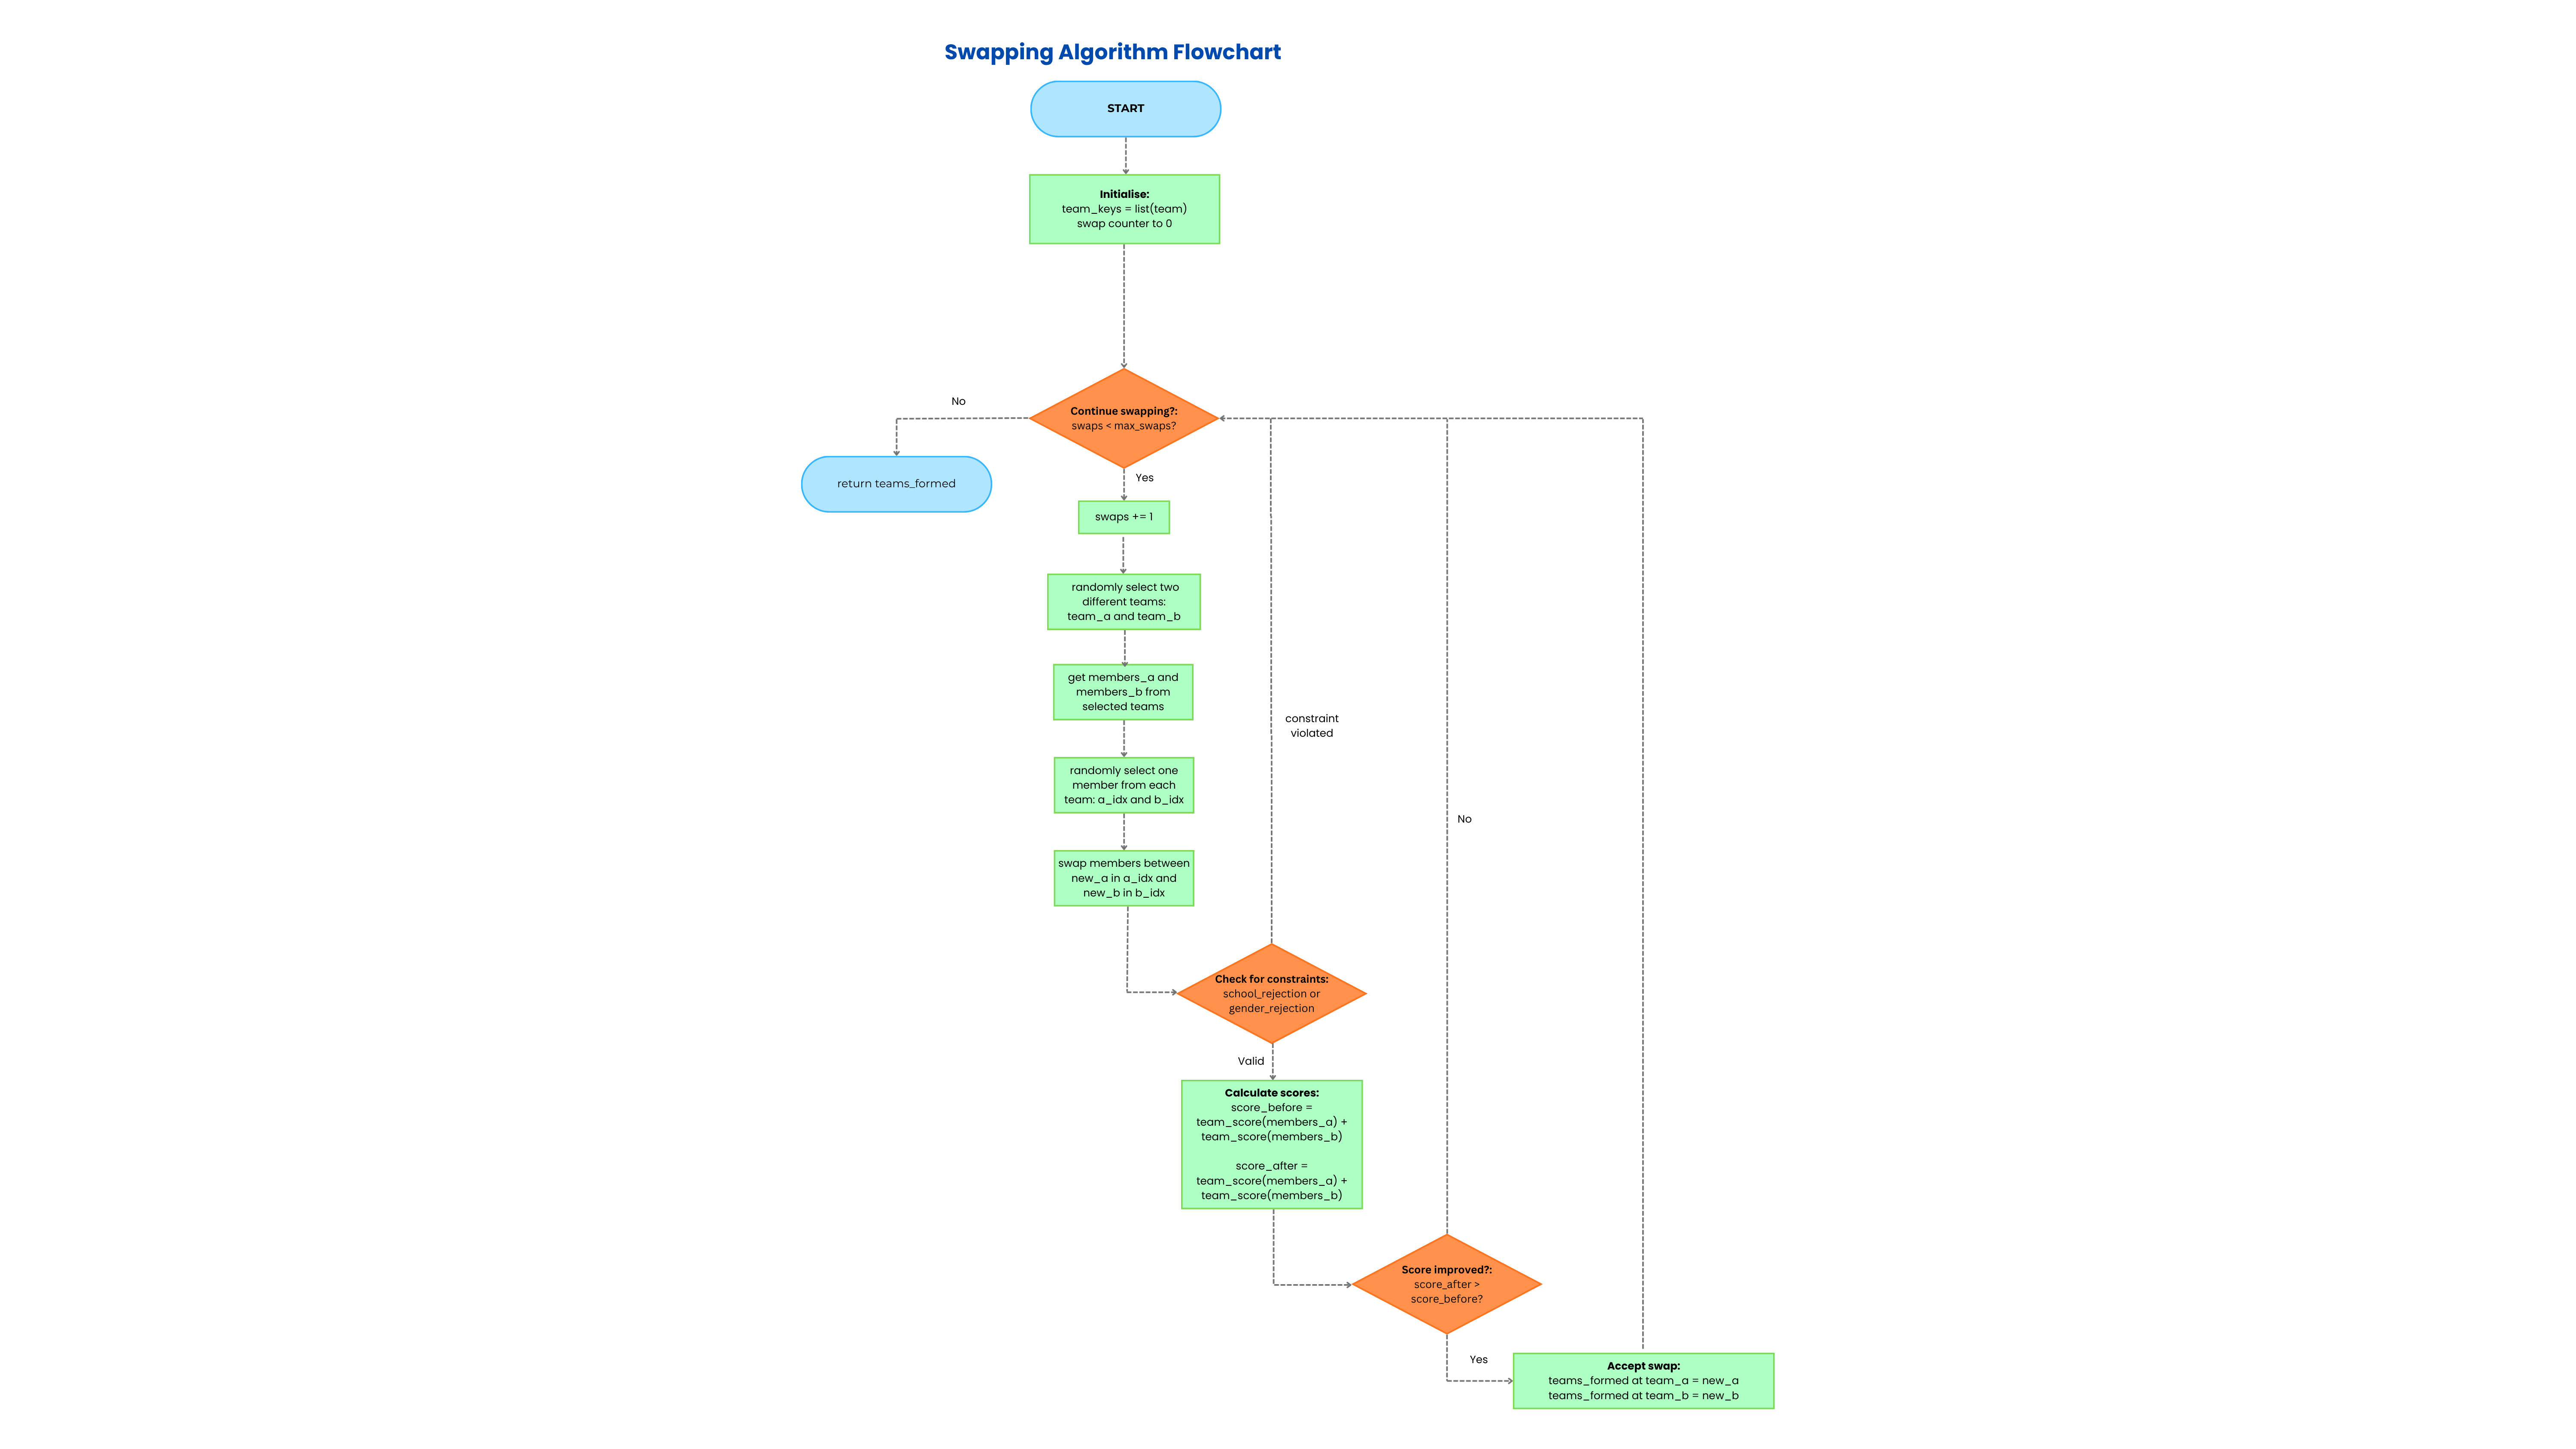

In [ ]:
from IPython.display import Image, display

display(Image(filename='assets/Swapping Algorithm Flowchart.png'))

In [ ]:
def optimize_swaps(teams_formed, dict_list_tutorial, max_swaps):
    team_keys = list(teams_formed.keys())
    swaps = 0

    while swaps < max_swaps:
        swaps += 1

        #randomly pick two different teams and members
        i, j = random.sample(range(len(team_keys)), 2)
        team_a, team_b = team_keys[i], team_keys[j]

        members_a = teams_formed[team_a]
        members_b = teams_formed[team_b]

        a_idx = random.randrange(len(members_a))
        b_idx = random.randrange(len(members_b))

        #make copies for testing
        new_a = members_a.copy()
        new_b = members_b.copy()
        new_a[a_idx], new_b[b_idx] = new_b[b_idx], new_a[a_idx]

        #check constraints
        reject_a = school_rejection(new_a) or gender_rejection(new_a, dict_list_tutorial)
        reject_b = school_rejection(new_b) or gender_rejection(new_b, dict_list_tutorial)

        if reject_a or reject_b:
            continue

        #compute scores before and after
        score_before = (
            team_score(members_a, dict_list_tutorial)
            + team_score(members_b, dict_list_tutorial)
        )
        score_after = (
            team_score(new_a, dict_list_tutorial)
            + team_score(new_b, dict_list_tutorial)
        )

        #accept if score increase
        if score_after > score_before:
            teams_formed[team_a] = new_a
            teams_formed[team_b] = new_b

    return teams_formed

### Function: `optimize_swaps(teams_formed, dict_list_tutorial, max_swaps)`

**Purpose**: Improves initial team formations by swapping students from two different teams to improve team diversity and fairness while abiding with gender and school constraint.

**Approach**:
- Initial formation from CGPA clustering approach might create a team with low diversity
- Strategic swaps can significantly improve team quality (e.g. from team score of 0.84 to 0.99)
- Swapping between 2 teams can only be done if the total score of 2 teams increase
- Must maintain gender and school constraints during swaps

**Input**:
- `teams_formed`: Dictionary of teams from initial formation
- `dict_list_tutorial1`: List of all students in the tutorial group (for constraint checking purpose)
- `max_swaps`: Maximum number of swap attempts

**Output**: Optimized dictionary of teams with improved diversity scores (close to maximum score)

**Step-by-step Process**:

#### Step 1: Initialize Swap Counter and Team Keys

```python
team_keys = list(teams_formed.keys())
swaps = 0
```
- Converts dictionary keys to list for random access
- Example: `team_keys = ['Team 1', 'Team 2', ..., 'Team 10']`
- Tracks how many swap attempts have been done
- Stop swap if number of swap has reach maximum swap

---

#### Step 2: Increment Counter for Each Iteration

```python
while swaps < max_swaps:
    swaps += 1  
```
- Counter incremented at the start of the iteration
- Count **all** attempts made, both rejected or accepted

**Why increment at start?**:
- Simpler logic, no need to increment at multiple accepted scenario
- Reduce processing time for large data set

---

#### Step 3: Randomly select two different teams

```python
i, j = random.sample(range(len(team_keys)), 2)
team_a, team_b = team_keys[i], team_keys[j]

members_a = teams_formed[team_a]
members_b = teams_formed[team_b]
```
- `random.sample(range(len(team_keys)), 2)` pick two different team keys randomly
- random sample method **guarantee** two teams picked is different
- Get the current team member from dictionary

**Example**
``` python
team_keys = ['Team 1', 'Team 2', 'Team 3', 'Team 4']
#random.sample(range(4), 2) might return: [1, 2]

i, j = 1, 2
team_a = 'Team 2'
team_b = 'Team 3'

members_a = teams_formed['Team 2']  # [Andrew, Bob, Charlie, Dickson, Emily]
members_b = teams_formed['Team 3']  # [Frank, Gabriel, Howard, Iris, Jack]
```

**Why we use random selection**
- Reduce time complexity
- Avoid bias toward spesific team (for example, if we use for loops, earlier team might be more likely to get swapped)
- Over large number of iteration, each team will get nearly equal chance of getting swapped
---

#### Step 4: Randomly Select Team Members to Swap

```python
a_idx = random.randrange(len(members_a))
b_idx = random.randrange(len(members_b))
```
- random.randrange(len(N)) will yield one random number from 0 to N-1
- Select one random member from each teams

---

#### Step 5: Create Copies and Perform Swap
```python
new_a = members_a.copy()
new_b = members_b.copy()

new_a[a_idx], new_b[b_idx] = new_b[b_idx], new_a[a_idx]
```
- `.copy()` create copy of the team member list
- Keep original team member if swapping fail to improve team score
- Simultaneously swap member of team a and team b

**Example**:

```
#before swap:
members_a = [Andrew, Bob, Charlie, Dickson, Emily]
members_b = [Frank, Gabriel, Howard, Iris, Jack]

#create copies:
new_a =  [Andrew, Bob, Charlie, Dickson, Emily]
new_b = [Frank, Gabriel, Howard, Iris, Jack]

#swap Bob from team a (index 1) with Iris from team b (index 3):
new_a[1], new_b[3] = new_b[3], new_a[1]

#after swap:
new_a = [Andrew, Iris, Charlie, Dickson, Emily]   # Iris joined Team A
new_b = [Frank, Gabriel, Howard, Bob, Jack]  # Bob joined Team B
```

---

#### Step 6: Validate Constraints

```python
reject_a = school_rejection(new_a) or gender_rejection(new_a, dict_list_tutorial1)
reject_b = school_rejection(new_b) or gender_rejection(new_b, dict_list_tutorial1)

if reject_a or reject_b:
    continue
```

- `school_rejection(new_a)`: Returns `True` if any school dominates (>50%)
- `gender_rejection(new_a, ...)`: Returns `True` if gender balance is off from tutorial class (±20%)
- `or`: If ANY of constraint fails → reject swap
- `if reject_a or reject_b`: If ANY team violates → skip this swap
- Both team must pass school and gender constraints for swap to be executed

**Example of Rejected Swaps**
``` python
#original Team A: [SSS, SSS, CCEB, SPMS, NBS]  
#current: SSS=2, CCEB=1, SPMS=1, NBS=1 (Valid)

#original Team B: [MAE, WKWSCI, SSS, ADM, MSE]
#current: All schools have 1 student (Valid)

#after attempting a swap that brings another SSS to Team A:
new_a = [SSS, SSS, SSS, SPMS, NBS]  

#school_rejection(new_a) = True (3 EEE > 50%)
#reject_a = True
#continue to the next iteration without executing swap

```
---

#### Step 7: Calculate Total Team Score after Swapping

```python
score_before = (
    team_score(members_a, dict_list_tutorial1)
    + team_score(members_b, dict_list_tutorial1)
)
score_after = (
    team_score(new_a, dict_list_tutorial1)
    + team_score(new_b, dict_list_tutorial1)
)
```


- `team_score()`: Return score for each team from 0-1
- `score_before`: Sum of original Team A + Team B scores
- `score_after`: Sum of new Team A + Team B scores
- We want to improve BOTH teams diversity and fairness simultaneously
- Over large number of iteration, we aimed to maximize total score of all team in tutorial group


**Example**:
``` python
Before swap:
Team A score: 0.85
Team B score: 0.78
score_before: 1.63

After swap:
Team A score: 0.91
Team B score: 0.82
score_after: 1.73

#swap accepted
```

---

#### Step 8: Accept only Improved Teams

```python
if score_after > score_before:
    teams_formed[team_a] = new_a
    teams_formed[team_b] = new_b
```
- Only accept swapping if total score improved
- If swap approved, the swap will be executed (teams_formed[team] = new_team)

**What Happen if Swap Accepted**
``` python
# Before acceptance:
teams_formed = {
    'Team 2':  [Andrew, Bob, Charlie, Dickson, Emily],    
    'Team 3': [Frank, Gabriel, Howard, Iris, Jack],
    ...
}

# After acceptance:
teams_formed = {
    'Team 2': [Andrew, Iris, Charlie, Dickson, Emily], #Iris move to team 2
    'Team 3': [Frank, Gabriel, Howard, Bob, Jack], #Bob move to team 3
    ...
}
```
**What Happen if Swap Rejected**
``` python
#nothing changes!
#teams_formed remains unchanged
#loop continues to next iteration
```

---

## 8. Multi-Attempt Team Formation Strategy


In [ ]:
student_list = read_csv('records.csv')
dict_list_records = create_tutorial_groups(student_list)

max_swaps = 400
all_tut_group_teams = {} #dict to store all students

#list to store scores (for graph only)
score_list_1 = []
score_list_2 = []

for tut_group, dict_list_tutorial in dict_list_records.items():
    repeat = True
    retry_count = 0
    best_score = 0
    best_teams = None

    while repeat:
        #use two phase algo
        retry_count += 1
        student_gpa_cluster = create_gpa_cluster(dict_list_tutorial, team_size)
        teams_formed = form_teams_from_clusters(student_gpa_cluster, team_size)
        initial_score = [team_score(members, dict_list_tutorial) for members in teams_formed.values()]

        teams_formed = optimize_swaps(teams_formed, dict_list_tutorial, max_swaps)
        team_scores = [team_score(members, dict_list_tutorial) for members in teams_formed.values()]

        min_score = min(team_scores)
        avg_score = sum(team_scores) / len(team_scores)

        #track best solution
        if min_score > best_score:
            best_score = min_score
            best_teams = teams_formed
            best_avg_score = avg_score
            best_initial_score = initial_score
            best_team_scores = team_scores

        #check threshold
        if (retry_count >= 10) or (min_score > 0.867 and not has_team_rejection(teams_formed, dict_list_tutorial)):
            score_list_1.extend(best_initial_score)
            score_list_2.extend(best_team_scores)
            all_tut_group_teams[tut_group] = best_teams
            break

**Purpose**: Apply the team formation algorithm (CGPA Clustering and Swap Optimization) accross 120 tutorial group in our dataset to ensure that each tutorial group have high quality teams that satisfy all constraint mentioned previously

**Global Variables**:
- `max_swaps`: Swap iterations per tutorial group
- `all_tut_group_teams`: Master dictionary storing final teams for all groups
- `score_list_1`: List tracking each team score after CGPA clustering (for graphing purpose)
- `score_list_2`: List tracking each team score after Swapping Optimization (for graphing purpose)

**Approach**:
- For each tutorial group, repeatedly apply team formation algorithm until minimum threshold passed
- Track best teams formed from multiple attempt and only accept team with all score above `0.867` and has no rejection
- Stop after 10 attempt even if no teams formed meet the threshold, use the best teams formed
- Process all 120 tutorial group automatically

---

### 8.1 Iterate Through Tutorial Group

```python
for tut_group_name, dict_list_tutorial in dict_list_records.items():
    repeat = True
    retry_count = 0
    best_score = 0
    best_teams = None
```

**Loop Structure**:
- Iterates through all tutorial groups (`G-1` through `G-120`)
- `tut_group_name`: String like `'G-30'`
- `dict_list_tutorial`: List of 50 student dictionaries in that group

**Tracking Variable**:
- `repeat = True`: Flag to control retry loop
- `retry_count = 0`: Tracks formation attempts, stop if exceed 10
- `best_score = 0`: Stores best minimum score achieved
- `best_teams = None`: Stores best team configuration

---

### 8.2 Retry Loop with Quality Threshold

```python
while repeat:
    retry_count += 1

    student_gpa_cluster = create_gpa_cluster(dict_list_tutorial, team_size)

    teams_formed = form_teams_from_clusters(student_gpa_cluster, team_size)
    initial_score = [team_score(members, dict_list_tutorial)
                    for members in teams_formed.values()]

    teams_formed = optimize_swaps(teams_formed, dict_list_tutorial, max_swaps)
```

- Keep creating new team formation until teams form meet minimum threshold
- `retry_count` will increment at the start of each iteration
- If `retry_count` reach 10, use best teams formed and continue to the next tutorial group

**Two Phase Team Formation**
1. **CGPA Clustering**
- Sort student from lowest to highest CGPA
- Create CGPA cluster to collect student with similar CGPA
- Distribute student from CGPA cluster into initial teams
- Each team will get 1 student from each cluster to ensure CGPA fairness
2. **Swap Optimization**
- Perform swapping optimization up to `max_swaps`
- Improve team quality while abiding constraint
- Enhance team score (e.g. from 0.6 to 0.98)
---

### 8.3 Evaluate Team Quality

```python
team_scores = [team_score(members, dict_list_tutorial) for members in teams_formed.values()]
min_score = min(team_scores)
avg_score = sum(team_scores) / len(team_scores)
```

- `team_scores`: List containing score of all teams accross tutorial group
- `min_score`: Smallest team score accross tutorial group
- `avg_score`: Average of all team score in a tutorial group
---

### 8.4 Track Best Solution

```python
  if min_score > best_score:
      best_score = min_score
      best_teams = teams_formed
      best_avg_score = avg_score
      best_initial_score = initial_score
      best_team_scores = team_scores
```
- Only update if current `min_score` is better than `best_score`
- Keep the best result across all attempts
- Store both phase 1 score (`best_initial_scores`) and phase 2 score (`best_team_scores`)


**Example Scenario**:
```
Attempt 1: min_score = 0.8 → Update best (first attempt)
Attempt 2: min_score = 0.79 Keep attempt 1 (worse)
Attempt 3: min_score = 0.84 → Update best (improved score)
Attempt 4: min_score = 0.93 → Stop at current attempt since threshold is already met
```


---

### 8.5 Check Stopping Criteria

```python
if (retry_count >= 10) or (min_score > 0.867 and not has_team_rejection(teams_formed, dict_list_tutorial)):
    repeat = False
    all_tut_group_teams[tut_group_name] = best_teams
    phase1_scores.extend(best_initial_score)
    phase2_scores.extend(best_team_scores)

    print(f"{tut_group_name} processed | min score: {best_score:.3f} | avg score: {best_avg_score:.3f} | retries: {retry_count}")
    break
```

**Exit Conditions**:
#### Condition 1: Maximum Retries Reached
```python
retry_count >= 10
```
- Iterations will be stopped after 10 attempts
- Prevent infinite looping for difficult tutorial group (e.g. group with imbalance gender proportion)
- Use best solution found in those 10 attempts

#### Condition 2: Quality Threshold Met
```python
(min_score > 0.867 and not has_team_rejection(teams_formed, dict_list_tutorial))
```
**Two requirement have to be met**
- Minimum Score Threshold: `min_score > 0.867`
- No constraint violation: `not has_team_rejection(...)`
- Reject any teams formation where atleast one team violates constraint

**Why 0.867 Threshold**

The cutoff of 0.867 represents the minimum acceptable score for the worst-performing team when gender balance is imperfect but still within acceptable limits. Recall the team scoring formula:
- 30% weight on school diversity
- 30% weight on cgpa fairness
- 40% weight on gender diversity

One of the most common issues of teams formed is gender imbalance (4 males 1 female or vice versa) which still pass gender rejection tolerance. To avoid this, we will make the quality threshold to be the maximum possible score of team with gender imbalance to ensure diverse and fair teams formed.

``` python
# Maximum possible score with 4:1 gender ratio:

# Best case - all different schools
School component = 0.30 × 1.0 = 0.30

# Best case - perfectly distributed CGPAs
CGPA component = 0.30 × 1.0 = 0.30

# Gender balance (40% weight):
Gender component = 0.40 × 0.667 = 0.267

# Total Maximum Score:
0.30 + 0.30 + 0.267 = 0.867
```


---

### 8.6 Output and Storage

```python
all_tut_group_teams[tut_group_name] = best_teams
score_list_1.extend(best_initial_score)
score_list_2.extend(best_team_scores)
```
- `all_tut_group_teams[tut_group_name]`: Adds to dictionary storing all team allocation
- Key: Tutorial group name (e.g., `'G-30'`)
- Value: Dictionary of 10 teams with members
---

## 9. CSV Export

In [ ]:
with open("FECD1_Team2_I Putu Dickson Partha Hartopo.csv", 'w') as file:
    file.write('Tutorial Group,Student ID,Name,School,Gender,CGPA,Team Assigned\n')
    for Tutorial_Group, Student_Team in all_tut_group_teams.items():
        for Team_Name, Members in Student_Team.items():
            for student in Members:
                row = [
                    Tutorial_Group,
                    student['Student ID'],
                    student['Name'],
                    student['School'],
                    student['Gender'],
                    student['CGPA'],
                    Team_Name
                ]
                written_line = ','.join(row)
                file.write(f"{written_line}\n")
    print("CSV created!")

CSV created!


**Purpose**: Write final team formation into a new csv file

**Approach**:
- Create a new 'team' column to indicate which team students belongs to
- Iterate through data structure to get student data
- Combine student data into row and write each row to new CSV file

### 9.1 Open File with Writing Mode
``` python
with open("teams_formed.csv", 'w') as file:
```
- `open("teams_formed.csv", 'w')`: Create a new file named " "
- `w` mode: Mode to create new file or overwrite the existing file
- `with`: Automatically close file after operation complete

---

### 9.2 Write CSV File Header
``` python
file.write('Tutorial Group,Student ID,Name,School,Gender,CGPA,Team\n')
```
- Defines column names for the CSV filef
- Columns include: Tutorial Group, Student ID, Name, School, Gender, CGPA, Team
- New column "Team" will be created to indicates which team each student belongs to

---

### 9.3 Iterate Through Tutorial Group
``` python
for Tutorial_Group, Student_Team in all_tut_group_teams.items():
```
- Loop through the all_tut_group_teams dictionary
- Tutorial_Group: Key = tutorial group name (e.g., "G-1, G-2, ..., G-120")
- Student_Team: Value = dictionary of teams within that tutorial group

**Data Structure**
``` python
all_tut_group_teams = {
    'G-1': {
        'Team 1': [student1, student2, student3, student4, student5],
        'Team 2': [student6, student7, student8, student9, student10],
        ...
    },
    'G-2': {
        'Team 1': [...],
        ...
    }
}
```

---

### 9.4 Iterate through Teams Within Tutorial Groups
``` python
for Team_Name, Members in Student_Team.items():
```
- Loop through teams within the current tutorial group
- Team_Name: Key = team name (e.g., "Team 1, Team 2, ..., Team 10")
- Members: Value = list of student dictionary within the team (e.g. [student1, student2, ..., student5])

**Data Structure**
``` python
Student_Team = {
    'Team 1': [student1, student2, student3, student4, student5],
    'Team 2': [student6, student7, student8, student9, student10],
        ...
    'Team 10': [student46, student47, student48, student49, student50]
    },

```

---
### 9.5 Iterate through Student Dictionary
``` python
for student in Members
```
- Loop through each student in the current team
- student: Dictionary consisting individual student data
**Data Structure**
``` python
student = {
    'Student ID': 'U1234567A',
    'Name': 'Alice Tan',
    'School': 'SCSE',
    'Gender': 'Female',
    'CGPA': '4.25'
}
```

---
### 9.6 Build Row for Each Student
``` python
row = [
    Tutorial_Group,
    student['Student ID'],
    student['Name'],
    student['School'],
    student['Gender'],
    student['CGPA'],
    Team_Name
]
```
**Row Example**
```python
row = [
    'G-1',    # Tutorial Group (from outer loop)
    'U1234567A',         # Student ID (from student dict)
    'Alice Tan',         # Name (from student dict)
    'SCSE',              # School (from student dict)
    'Female',            # Gender (from student dict)
    '4.25',              # CGPA (from student dict)
    'Team 1'             # Team Name (from middle loop)
]
```

---
### 9.7 Format and Write Each Row to New CSV File
``` python
written_line = ','.join(row)
file.write(f"{written_line}\n")
```
- `written_line = ','.join(row)`: Convert list into comma separated string
- Result: `"G-1,U1234567A,Alice Tan,SCSE,Female,4.25,Team 1"`
- `file.write(...)`: Writes the formatted string to file
- `\n`: Adds newline character to move to next row
- Each student gets one row in the CSV File, with total 6001 row (1 header + 6000 students)

**Done!**

## Algorithm Evaluation

### 1. Performance Analysis

To evaluate our team formation algorithm, we will plot the score of 1200 teams formed in Phase 1 (CGPA clustering) and Phase 2 (Swapping Optimizations) using histogram. As a baseline, we will also plot the score of 1200 teams formed using completely random allocation. We will compare the overall mean, median, standard deviation, and the effectiveness of team formation algorithm in every case.



In [ ]:
def calculate_stats(scores):
    n = len(scores)
    sorted_scores = sorted(scores)
    median = (sorted_scores[n//2] + sorted_scores[(n-1)//2]) / 2
    mean = sum(scores) / n
    return mean, median

#### Statistical Calculation Function

**Input**: List of team scores

**Ouput**: Mean, Standard Deviation, and Median of the scores

In [ ]:
score_list_0 = []
for tut_group_name, dict_list_tutorial in dict_list_records.items():
    total_students = len(dict_list_tutorial)
    num_teams = total_students // team_size

    shuffled_students = dict_list_tutorial.copy()
    random.shuffle(shuffled_students)
    random_teams = {}
    for i in range(num_teams):
        team_members = shuffled_students[i * team_size:(i + 1) * team_size]
        random_teams[f'Team {i + 1}'] = team_members

    #random baseline score
    phase0 = [team_score(members, dict_list_tutorial)
                    for members in random_teams.values()]

    score_list_0.extend(phase0)

#### Creating Teams using Random Allocation


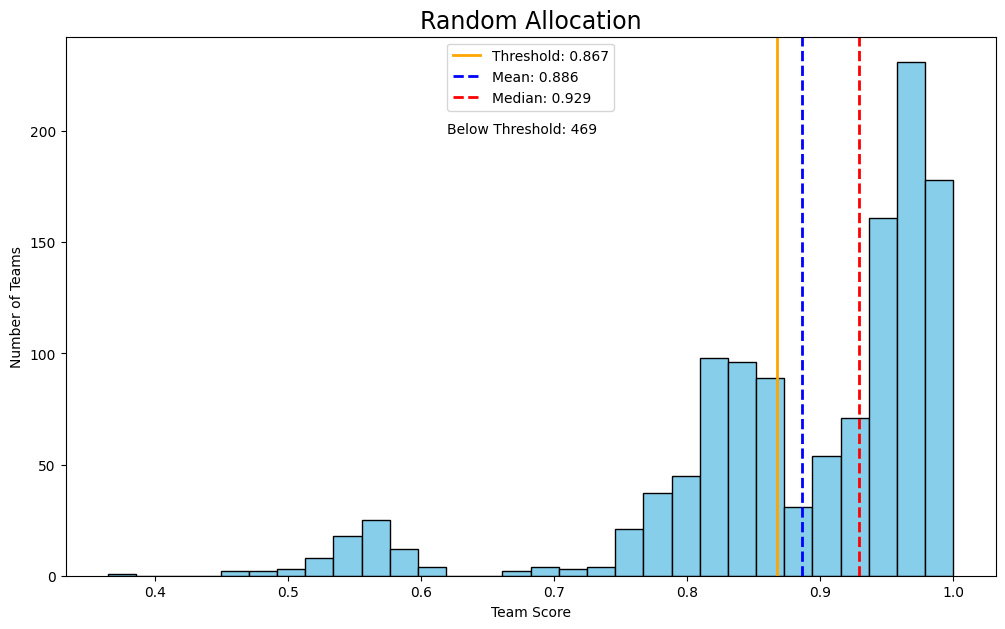

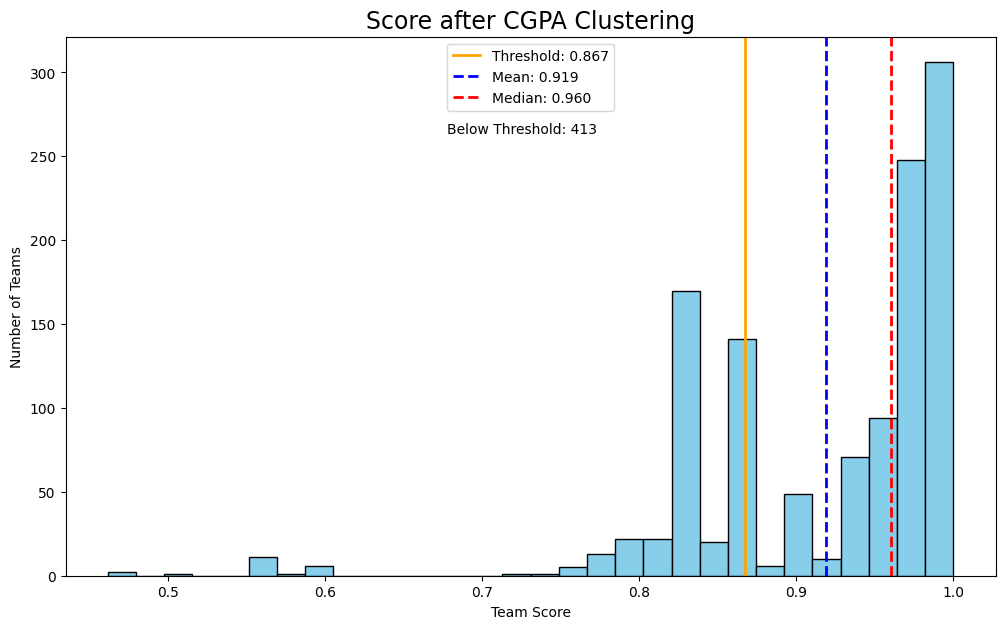

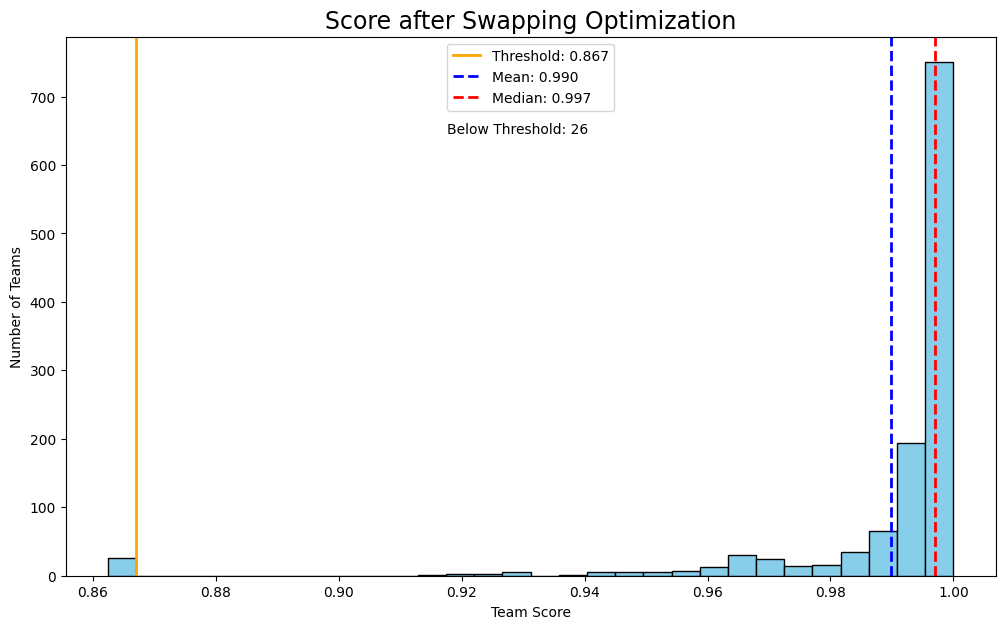

In [ ]:
def plot_histo(score_list, title):
    mean, median = calculate_stats(score_list)
    tres = 0.867

    plt.figure(figsize=(12, 7))
    plt.hist(score_list, bins=30, color='skyblue', edgecolor='black')

    plt.xlabel("Team Score")
    plt.ylabel("Number of Teams")
    plt.title(title, fontsize = 17)

    #mean, median, tres line
    plt.axvline(x = 0.867, lw = 2, color ='orange', label = f'Threshold: {tres}')
    plt.axvline(x = mean, lw = 2, ls = '--', color ='blue', label = f'Mean: {mean:.3f}')
    plt.axvline(x = median, lw = 2, ls = '--', color ='red', label = f'Median: {median:.3f}')

    #count team below tres
    below_tres = sum(score < tres for score in score_list)
    plt.text(0.41, 0.82, f'Below Threshold: {below_tres}', transform=plt.gca().transAxes)

    plt.legend(loc='upper center')
    plt.show()


plot_histo(score_list_0, 'Random Allocation')
plot_histo(score_list_1, 'Score after CGPA Clustering')
plot_histo(score_list_2, 'Score after Swapping Optimization')

As shown in the histogram above, in the random allocation scenario, the mean team score is already quite high (**~0.88/1.00**). This occurs because most of the tutorial groups have diverse gender and school distribution. Thus, even random allocation will yield high quality score. However, there are around **450-500** teams with scores below our threshold, indicating that there are gender imbalance, school imbalance, or CGPA unfairness.

After Phase 1 (CGPA clustering), we can see moderate improvement where the mean score increased to around **0.92/100**. However, there are still **400-450** teams that break our gender or school majority rules.

Ultimately, after Phase 2 (Swapping Optimizations), we can see the final result is excellent with median of around **0.997/1.0** and mean of **0.99/1.0**. Moreover, there are only **20-30** teams with scores below threshold, which is expected given that there are several tutorial group with imbalanced gender distribution and school distribution.

---



### 2. Time and Space Complexity

**Time Complexity and Space Complexity List**


We will use the following notation:

- n: The number of students per tutorial group (50)
- m: Maximum swaps allowed (400)
- t: The number of tutorial groups (120)


| Algorithm Function | Time Complexity | Space Complexity |
| :- | -: | :-: |
| `read_csv` | O(n) | O(n)
| `create_tutorial_groups` | O(n) | O(n)
| `simpson_raw_score ` | O(1) | O(1)
| `simpson_diversity_count` | O(1) | O(1)
| `gpa_fairness_count` | O(n) | O(n)
| `team_score` | O(n) | O(n)
| `create_gpa_cluster` | O(n log(n)) | O(n)
| `form_teams_from_clusters` | O(n) | O(n)
| `optimize_swaps` | O(m n) | O(n)
| two-phase algorithm | O(n$^{2}$ + mn) | O(n)
| **overall** | O(t(n$^{2}$ + mn)) | O(n)

---

**Empirical Usual Run Time**


After running the algorithm multiple times, we can see that our algorithm takes around 20s to run. This is acceptable given the large datasets and complex assessment that we are imposing

---

## Challenge and Constraint

### 1. Diversity Measure Choice

**Problem**

When we first tackled the project, we search common diversity measures at https://en.wikipedia.org/wiki/Diversity_index and https://bio.libretexts.org/Courses/Gettysburg_College/01%3A_Ecology_for_All/22%3A_Biodiversity/22.02%3A_Diversity_Indices. We narrowed it down to 2 choices, Simpson Index and Shannon Index.

**Comparison of Simpson Index with Shannon Index**

| Feature | Simpson Index | Shannon Index |
| :-: | :-: | :-: |
| Method | Calculate Probability of Two Element Differs | Entropy (Uncertainty of Predicting A Category)
| Penalize Dominance | Strongly | Moderately
| Rewards Rare Category | Weakly | Strongly
| Ease of Interpretation | Easy | Hard
| Calculation Complexity | Moderate | High

Shannon Index can be calculated using the formula:

$$ -\sum p_{i} \cdot ln(p_{i}) $$

After normalization, here is the comparison of Simpson Index and Shannon Index score (normalized)

| Team Composition | Proportion | Simpson Index | Shannon Index |
| :-: | :-: | :-: | :-: |
| 3 Male 2 Female | [0.6, 0.4] | 1.00 | 1.00 |
| 4 Male 1 Female | [0.8, 0.2] | 0.67 | 0.74 |
| [2 SSS, 2 CCDS, 1 NBS] |  [0.4, 0.4, 0.2] | 0.8 | 0.66 |
| [2 SSS, 1 CCDS, 1 NBS, 1 MAE] | [0.4, 0.2, 0.2, 0.2] | 0.9 | 0.83 |

As it can be seen from the comparison between 3 Male 2 Female and 4 Male 1 Female, Simpson Index gives larger penalties for a team that is dominated by a single category than Shannon Index. Moreover, Shannon Index fluctuates significantly if there is a new rare category. Thus, for our case which only consists of 5 people per team, we favor the use of Simpson Index

### 2. Inconsistent Maximum Score

**Problem**

When we applied Simpson Index formula to calculate the diversity of gender and school, we found that Simpson Diversity index gives different maximum scores for different categories. For example:
- Gender (2 categories): The most diverse team is 3 males 2 females with score 0.6
- School (>10 categories): The most diverse team is team where all team member are from different school with score 1.0

This created an unfair comparison problem where we could not compare the diversity accross two categories directly

**Our Solution**

We divide the Simpson Diversity score by the maximum score achievable.

``` python
normalized_score = simpson_index / maximum_possible_score
```

The most diverse teams with given number of existing categories is team occurs when student is distributed as evenly as possible. We first need to count how many categories available and distribute it evenly accross all categories. Example:

**Genders (2 categories, 5 student)**
- There is only 2 genders in dataset, so the most diverse team is 3 males 2 females or 3 females 2 males
- Maximum Simpson Score is 0.6, which will be our normalizing factor
- We divide normal Simpson Score with this Maximum Score

By normalizing the score, we ensure that all metrics will yield score from 0 to 1.

### 3. Constraint Enforcement Issues

**Problem**
To ensure there is no team dominated by a gender or a school, we initially create a hard rejection constraint where we only accept teams with 3 females 2 males vice versa and teams where 3 or more students do not come from the same school. However, our algorithm crashed as there are tutorial groups with more than 30 females or more than 30 males. This makes our hard rejection constraint impossible to be applied

**Our Solution**
Instead of using hard constraint, we implemented a conditional constraint where we only reject teams with female proportion that deviates more than 20% with the respective tutorial group female proportion. By using this approach, our algorithm will not reject teams that are dominated by males or females if the tutorial group itself is dominated by a gender.

### 4. Large Data Set and Computational Inefficiency

**Problem**

Initially, we used a swapping algorithm that iterates through teams and then iterates through team members to check whether two teams have rejection or could be improved.

``` python
for team_a in all_teams:
    for team_b in all_teams:
        for member_a in team_a:
            for member_b in team_b:
```
 However, this is extremely time consuming as we need to iterate through multiple data structure, which explodes run time. Moreover, most swaps will usually done for earlier team in the group, leaving small room for exploration.


**Our Solution**

We use random choice to choose two teams and two member and then check whether there is rejection or the score improved.

```python
for iteration in range(max_swaps):
    team_a, team_b = random.sample(tutorial group)
    member_a = random.choice(team_a)
    member_b = random.choice(team_b)
```

By using this approach, we significantly reduce run time to around 20s and every team has roughly equal chance of being swapped for large number of iterations.

### 5. Determining the Optimal Number of Swaps

**Problem**

If the number of swaps is too low, we end up with mediocre result of the quality of team. But if we do too much swaps, the run time of the algorithm will be extremely long

**Our Solution**

By trial and error, we see from the that after 400 swaps, the team score only improve by a tiny margin. 400 swaps also doesn't cause the algorithm to have large run time so we decide to use 400 swaps.

### 6. Handling Edge Cases

**Problem**

Even after CGPA clustering and Swapping Optimization, the algorithm might produce team with low quality in some rare edge cases. This might happen due to bad luck on initial CGPA clustering or because of demographic imbalance within tutorial group.

**Our Solution**

Instead of directly accepting the result on one try, we run the algorithm multiple times (at most 10 times) and select the best outcome. We create a minimum score threshold to ensure that the algorithm doesn't produce low quality teams. We also keep track of best teams and their best minimum score that will be used if the algorithm hit the retry limit

---


## Conclusion

In conclusion, our Team Allocation Simulator successfully achieved its goal of forming diverse and fair student teams. By incorporating CGPA Clustering and Swapping Optimization, using diversity and fairness evaluation metric such as Simpson Diversity Index and GPA Fairness Score, the algorithm create teams with gender diversity, school diversity, and CGPA fairness. The implementation of gender and school rejection constraint also further improve team's quality, where fewer than 2.5% of the team being insufficiently diverse due to demographics limitations.

---

## Appendix: Use of AI Tools Declaration


| Full Name| Date | A or B  |
| :- | -: | :-: |
| Chua Yee Han | 9 Nov 2025 | A
| Hoo Jia Mei | 9 Nov 2025 | A
| Ho Jun De Dillon Trevor | 9 Nov 2025 | A
| I Putu Dickson Partha Hartopo | 9 Nov 2025 | A